## Calibration Uncertainty Systematic — Scaling the Signal Amplitude

#### Importing Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from joblib import Parallel, delayed
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.analysis import plot_summary
import matplotlib.pyplot as plt
import camb
import healpy as hp

_ = torch.manual_seed(42)
_ = np.random.seed(0)

#### Defining Functions

In [4]:
def get_camb_spectrum(theta, lmax=3000):
    """Runs CAMB physics engine for a specific set of parameters."""
    H0_val, ombh2_val, omch2_val, As_val, ns_val = theta

    pars = camb.set_params(
        H0=H0_val, ombh2=ombh2_val, omch2=omch2_val,
        mnu=0.06, omk=0, tau=0.06,
        As=As_val, ns=ns_val,
        halofit_version='mead', lmax=lmax
    )

    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK', raw_cl=True)['total']

    # Return just the TT spectrum
    return powers[:, 0]


def generateMock(cl, nls=None, lmax=3000, beam_fwhm=5.0):
    """Turns a pure C_ell spectrum into a noisy 2D sky map observation."""
    if len(cl) < lmax + 1:
        cl = np.pad(cl, (0, lmax + 1 - len(cl)))
    cl = cl[:lmax+1]

    # 1. Generate the True Sky (Cosmic Variance)
    cmb_alm = hp.synalm(cl, lmax=lmax)

    # 2. Apply Telescope Blur
    if beam_fwhm is not None and beam_fwhm != 0:
        beam = hp.gauss_beam(beam_fwhm / 60 / 180 * np.pi, lmax=lmax)
    else:
        beam = np.ones(lmax + 1)

    # 3. Add Telescope Noise (The Splits)
    if nls is not None:
        obs_alms = []
        for nl in nls:
            nl_formatted = nl[:lmax+1] if len(nl) >= lmax+1 else np.pad(nl, (0, lmax+1-len(nl)))
            noise = hp.synalm(nl_formatted, lmax=lmax)
            obs_alms.append(hp.almxfl(cmb_alm, beam) + noise)
        return np.array(obs_alms)
    else:
        return hp.almxfl(cmb_alm, beam) if beam_fwhm != 0 else cmb_alm


def getCompression(param_dict, derivatives, beam_fwhm=None, noise_cl=None):
    """
    A simple implementation of the MOPED algorithm.
    Assumes no dependence of cov mat on parameters (e.g. https://arxiv.org/pdf/1204.4724)
    Compressor is then: grad_mu @ C^{-1} @ (d - mu).
    Note: Match the beam and noise to the splits above.
    """
    lmax = param_dict['lmax']

    def getSpectrum(params):
        # FIX: Strip 'lmax' from the dict and add fixed physical params explicitly,
        # so getSpectrum uses the same physics (mnu, omk, tau) as get_camb_spectrum.
        camb_params = {k: v for k, v in params.items() if k != 'lmax'}
        pars = camb.set_params(
            mnu=0.06, omk=0, tau=0.06,
            halofit_version='mead', lmax=lmax,
            **camb_params
        )
        results = camb.get_results(pars)
        powers = results.get_cmb_power_spectra(pars, CMB_unit='muK', raw_cl=True)['total'][2:3001, 0]
        if noise_cl is None:
            noise = 0
        else:
            noise = noise_cl[2:3001]
        if beam_fwhm is not None:
            beam = hp.gauss_beam(beam_fwhm / 60 / 180 * np.pi, lmax=lmax)[2:]
        else:
            beam = np.ones(3001)[2:]
        return powers * beam**2 + noise

    fiducial = getSpectrum(param_dict)
    cov_mat = 2. / (2 * np.arange(2, 3001) + 1) * fiducial**2
    derivs = []
    for deriv_name in derivatives.keys():
        step = param_dict[deriv_name] * derivatives[deriv_name]
        deriv_params = dict(param_dict)
        deriv_params[deriv_name] += step
        up = getSpectrum(deriv_params)
        deriv_params = dict(param_dict)
        deriv_params[deriv_name] -= step
        down = getSpectrum(deriv_params)
        #if deriv_name == 'As':
         #   step *= 1e10  # As is measured in units of 10^-10 ## weve commented out as were just traiing for raw figure
        derivs.append((up - down) / (2 * step))
        print(deriv_name)
    derivs = np.array(derivs)

    def compressor(data):
        data = data[2:]  # Remove monopole and dipole
        return np.dot(derivs, (data - fiducial) / cov_mat)

    return fiducial, cov_mat, derivs, compressor


def blanket_simulator(theta, compressor, nl_split, lmax=3000, beam_fwhm=5.0,
                      seed_cmb=None, seed_noise=None, amplitude_scale=1.0):
    """
    Replaced single 'seed' with separate seed_cmb and seed_noise so that
    two observations can share the same CMB sky realisation (same seed_cmb)
    while having independent noise (same or different seed_noise) and different
    noise spectra (nl_split). Also added np.asarray() to safely accept both
    numpy arrays and torch tensors as theta.

    amplitude_scale: multiplicative factor applied to the observed C_ell
    before compression (1.0 = no systematic, >1.0 = calibration uncertainty).
    This is the 'calibration uncertainty' systematic recommended by supervisor.
    """
    # FIX: Convert theta to numpy so this works whether called with a numpy
    # array or a torch tensor (e.g. theta_true).
    theta = np.asarray(theta, dtype=float)

    # Get pure theory spectrum
    cl_pure = get_camb_spectrum(theta, lmax=lmax)
    cl_pure = cl_pure[:lmax+1]

    # Draw the CMB sky realisation (controlled by seed_cmb)
    if seed_cmb is not None:
        np.random.seed(int(seed_cmb))
    cmb_alm = hp.synalm(cl_pure, lmax=lmax)

    # Apply beam
    beam = hp.gauss_beam(beam_fwhm / 60 / 180 * np.pi, lmax=lmax)
    cmb_alm_beamed = hp.almxfl(cmb_alm, beam)

    # Draw noise realisation (controlled independently by seed_noise)
    if seed_noise is not None:
        np.random.seed(int(seed_noise))
    nl_formatted = np.asarray(nl_split)[:lmax+1]
    noise_alm = hp.synalm(nl_formatted, lmax=lmax)

    # Combine and compress
    cl_obs = hp.alm2cl(cmb_alm_beamed + noise_alm, lmax=lmax)
    # Apply calibration uncertainty: scale the observed signal amplitude
    cl_obs = cl_obs * amplitude_scale
    return np.asarray(compressor(cl_obs), dtype=float)


def define_uniform_prior():
    low_bounds  = torch.tensor([60.0, 0.020, 0.10, 1.5e-9, 0.90])
    high_bounds = torch.tensor([75.0, 0.025, 0.14, 2.5e-9, 1.02])
    prior = BoxUniform(low=low_bounds, high=high_bounds)
    return prior


def generate_theta(prior, num_simulations):
    theta = prior.sample((num_simulations,))
    return theta


def parallel_simulate(theta, seeds, compressor, nl_split, beam_fwhm=5.0, amplitude_scale=1.0):
    """
    Passes seed_cmb and seed_noise separately. Noise seed is offset by
    1_000_000 from the CMB seed to guarantee the two draws are independent
    while still being fully reproducible from a single seeds array.
    amplitude_scale is forwarded to blanket_simulator for calibration uncertainty tests.
    """
    num_workers = 8
    x = Parallel(n_jobs=num_workers)(
        delayed(blanket_simulator)(
            theta_val.numpy(), compressor, nl_split,
            beam_fwhm=beam_fwhm,
            seed_cmb=int(s), seed_noise=int(s) + 1_000_000,
            amplitude_scale=amplitude_scale
        )
        for theta_val, s in zip(theta, seeds)
    )
    return torch.tensor(np.array(x), dtype=torch.float32)

def plot_checker(x, x_obs):
    # Safely convert to numpy if it's a PyTorch tensor
    x_np = x.numpy() if torch.is_tensor(x) else np.array(x)
    
    # Dynamically calculate the limits based on your simulated data
    min_vals = x_np.min(axis=0)
    max_vals = x_np.max(axis=0)
    
    # Add a 10% visual padding around the edges of the plot
    padding = 0.1 * (max_vals - min_vals)
    dynamic_limits = np.column_stack((min_vals - padding, max_vals + padding)).tolist()

    _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        limits=dynamic_limits,  # Uses our perfectly scaled dynamic limits
        figsize=(10, 10),       # Increased to 10x10 for the 5 parameters
        labels=[
            r"$x_{H_0}$", 
            r"$x_{\Omega_b h^2}$", 
            r"$x_{\Omega_c h^2}$", 
            r"$x_{A_s}$", 
            r"$x_{n_s}$"
        ] # Named after the parameters they compress
    )

def make_compressor(fiducial, cov_mat, derivs):
    """
    Reconstruct the MOPED compressor closure from its saved numpy arrays.
    Called after loading results to avoid pickle issues with local functions.
    """
    def compressor(data):
        data = data[2:]  # Remove monopole and dipole
        return np.dot(derivs, (data - fiducial) / cov_mat)
    return compressor


In [5]:
def train_net_generate_samples(x, theta, x_obs, prior, verbose, max_epoch, true_val):

    inference = NPE(prior=prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(
        max_num_epochs=max_epoch, stop_after_epochs=30
    )
    posterior_direct = inference.build_posterior(density_estimator=posterior_net, sample_with="direct")
    posterior_mcmc   = inference.build_posterior(density_estimator=posterior_net, sample_with="mcmc")
    samples = posterior_mcmc.sample((1_000,), x=x_obs)

    if verbose:
        _ = plot_summary(
            inference,
            tags=["training_loss", "validation_loss"],
            figsize=(10, 2),
        )

        print(posterior_mcmc)
        print("Observation: ", x_obs)

        #calculate dynamic limits:

        #rescale as
        plot_samples = samples.clone() if torch.is_tensor(samples) else np.copy(samples)
        plot_true = true_val.clone() if torch.is_tensor(true_val) else np.copy(true_val)
        
        # Multiply the 4th parameter (A_s, index 3) by 1 billion
        plot_samples[:, 3] *= 1e9
        plot_true[3] *= 1e9


        samples_np = plot_samples.numpy() if torch.is_tensor(samples) else np.array(samples)
        true_np = plot_true.numpy() if torch.is_tensor(true_val) else np.array(true_val)

        min_vals = samples_np.min(axis=0)
        max_vals = samples_np.max(axis=0)
        padding = 0.2 * (max_vals - min_vals)
        plot_min = np.minimum(min_vals - padding, true_np - padding)
        plot_max = np.maximum(max_vals + padding, true_np + padding)

        dynamic_limits = np.column_stack((plot_min, plot_max)).tolist()

        _ = pairplot(
            plot_samples,
            points=plot_true[None, :],
            limits=dynamic_limits,
            figsize=(10, 10),
            labels=[r"$H_0$", r"$\Omega_b h^2$", r"$\Omega_c h^2$", r"$10^9 A_s$", r"$n_s$"]
        )

    return samples, posterior_mcmc, posterior_direct, inference

#### Define Fiducial Baseline

In [4]:
# Define your Baseline Universe and Step Sizes
fiducial_params = {
    'H0': 67.5, 'ombh2': 0.022, 'omch2': 0.122,
    'As': 2e-9, 'ns': 0.965, 'lmax': 3000
}
derivatives_frac = {
    'H0': 0.001, 'ombh2': 0.005, 'omch2': 0.005, 'As': 0.005, 'ns': 0.005
}

# Noise spectrum — consistent across both splits (systematic is beam only)
nl_base = np.ones(3001) * (20 / 60 / 180 * np.pi)**2

# Beam FWHM in arcminutes — fixed for both splits (beam is NOT the systematic here)
beam_base = 5.0  # arcmin

# Calibration uncertainty: multiplicative factor on the observed signal amplitude
# Split 1 uses amplitude_scale=1.0 (null), Split 2 uses amplitude_scale=amplitude_systematic
amplitude_null       = 1.0       # no systematic
amplitude_systematic = 1.00075     # 0.075% upward rescaling of signal (calibration uncertainty)

# Build Compressor using the null instrument (beam_base, nl_base)
# Compressor is fixed at the null — intentional mismatch with systematic data
fiducial, cov, derivs, my_compressor = getCompression(
    param_dict=fiducial_params,
    derivatives=derivatives_frac,
    beam_fwhm=beam_base,
    noise_cl=nl_base
)


H0
ombh2
omch2
As
ns


In [5]:
# Define true universe
# FIX: kept as torch.tensor so true_val[None,:] works in pairplot
theta_true = torch.tensor([67.5, 0.022, 0.122, 2e-9, 0.965])

num_simulations = 5_000
prior = define_uniform_prior()
theta = generate_theta(prior, num_simulations)

# Each simulation gets a unique seed so parallel workers draw independent
# CMB + noise realisations and don't duplicate each other.
unique_seeds = np.random.randint(0, 1_000_000, size=num_simulations)

# FIX: Locked-in seeds for the 'true' observation so both splits share the
# same underlying CMB sky (same seed_cmb) and the same noise realisation
# (same seed_noise). The ONLY difference between x_obs_1 and x_obs_2 is
# therefore the amplitude_scale (null=1.0 vs amplitude_systematic), which is exactly
# what we want to isolate.
TRUE_SEED_CMB   = 12345
TRUE_SEED_NOISE = 99999


In [6]:

# Data split 1 — null (baseline beam, baseline noise)
x_obs_1 = torch.tensor(
    blanket_simulator(theta_true.numpy(), my_compressor, nl_base,
                      beam_fwhm=beam_base,
                      seed_cmb=TRUE_SEED_CMB, seed_noise=TRUE_SEED_NOISE),
    dtype=torch.float32
)
x_train_1 = parallel_simulate(theta, unique_seeds, my_compressor, nl_base,
                               beam_fwhm=beam_base)


In [7]:

# Data split 2 — calibration uncertainty systematic (signal amplitude scaled up by amplitude_systematic)
x_obs_2 = torch.tensor(
    blanket_simulator(theta_true.numpy(), my_compressor, nl_base,
                      beam_fwhm=beam_base,
                      seed_cmb=TRUE_SEED_CMB, seed_noise=TRUE_SEED_NOISE,
                      amplitude_scale=amplitude_systematic),
    dtype=torch.float32
)
x_train_2 = parallel_simulate(theta, unique_seeds, my_compressor, nl_base,
                               beam_fwhm=beam_base,
                               amplitude_scale=amplitude_systematic)


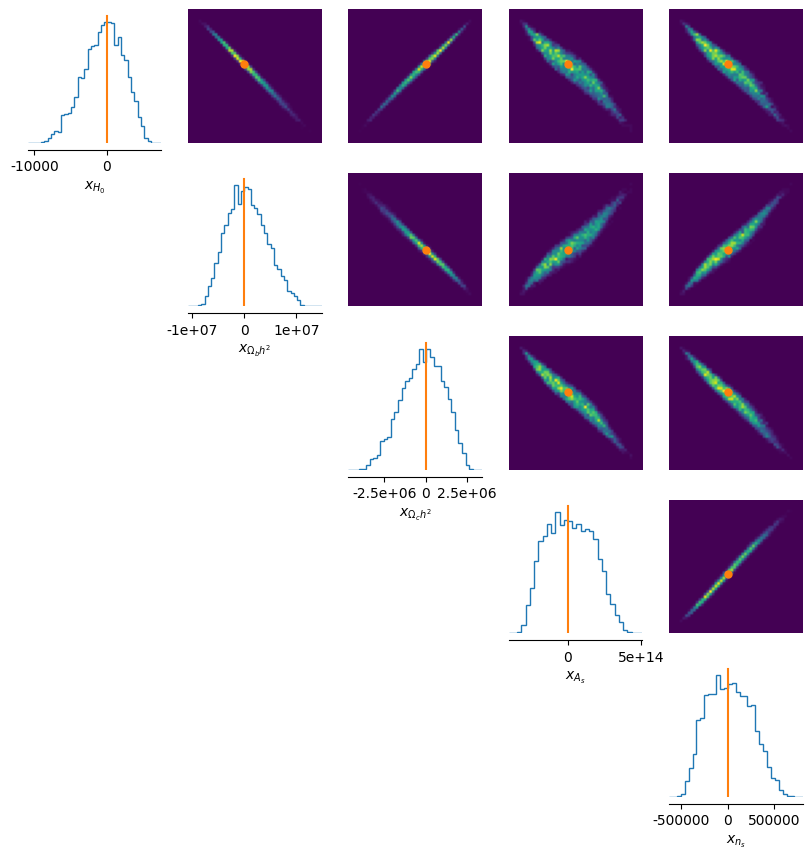

In [8]:
plot_checker(x_train_1, x_obs_1)

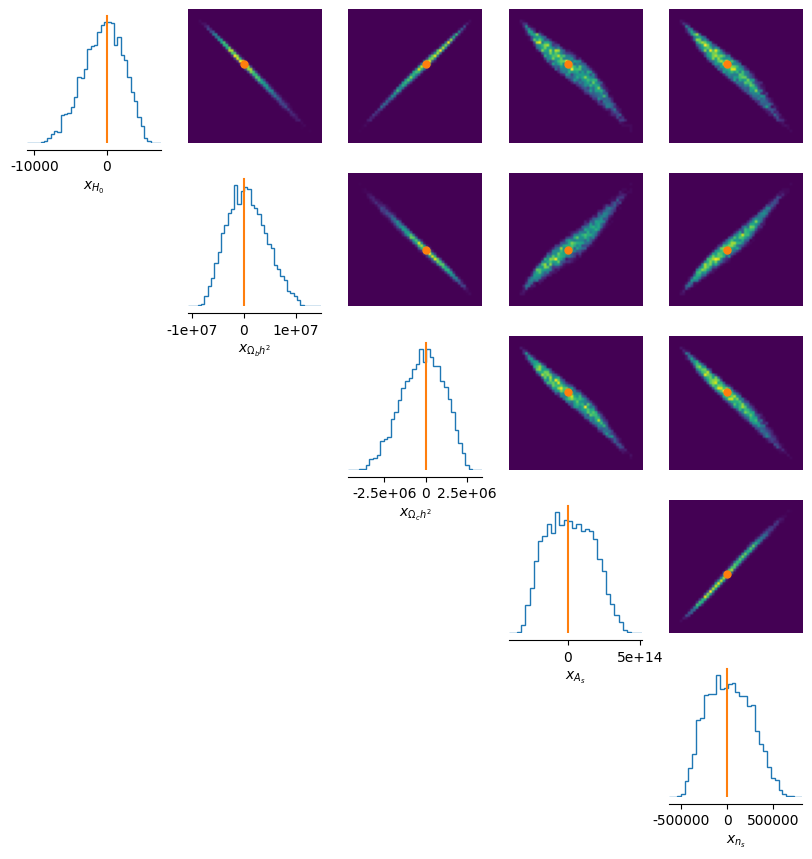

In [9]:
plot_checker(x_train_2, x_obs_2)

 Neural network successfully converged after 349 epochs.

/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/data/vault/jv447/repos/Part-III-Research-Project/sbi-logs/NPE_C/2026-04-02T21_13_23.573196' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  tensor([ 1.8259e+01,  2.7598e+03,  9.4160e+03, -5.2163e+11, -2.5927e+02])


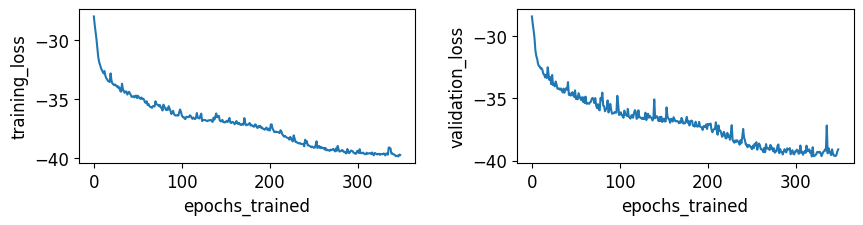

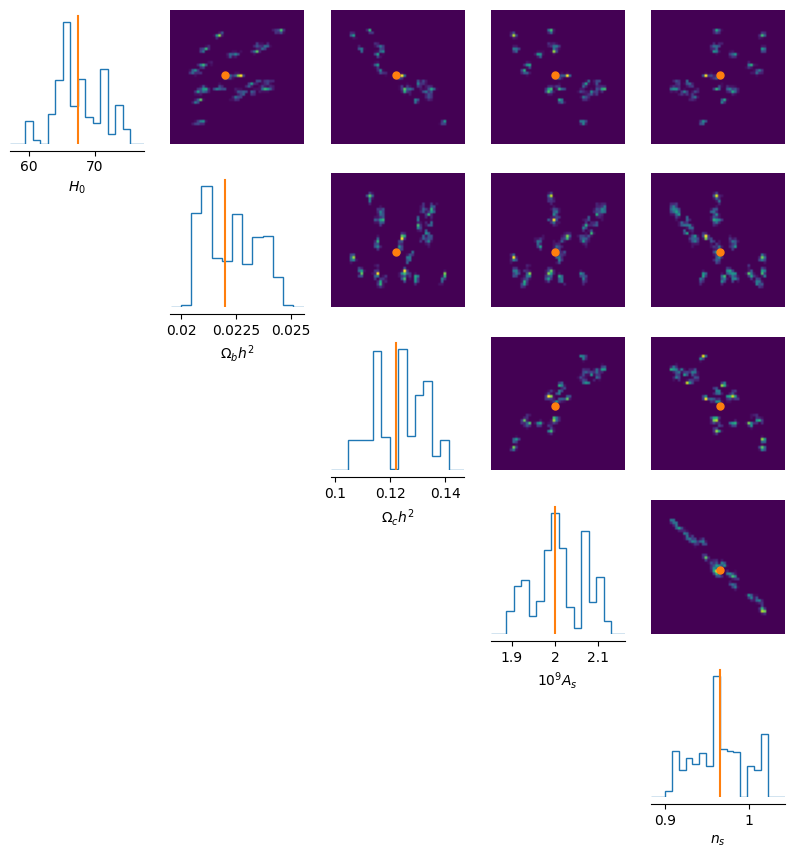

In [10]:
samples1, posterior1_mcmc, posterior1_direct, inference1 = train_net_generate_samples(
    x_train_1, theta, x_obs_1, prior, verbose=True, max_epoch=1000, true_val=theta_true
)

 Neural network successfully converged after 289 epochs.

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/data/vault/jv447/repos/Part-III-Research-Project/sbi-logs/NPE_C/2026-04-02T21_22_35.159288' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  tensor([3.3843e+00, 2.7572e+04, 2.7771e+03, 3.8139e+11, 1.2086e+03])


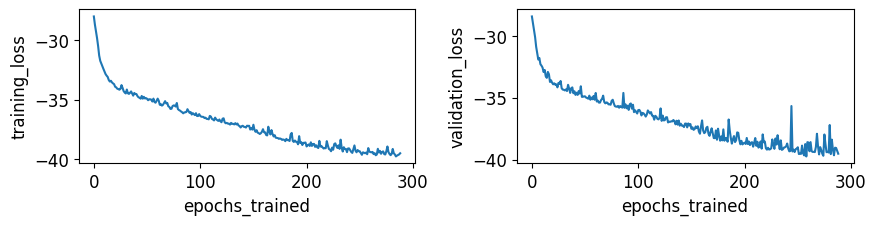

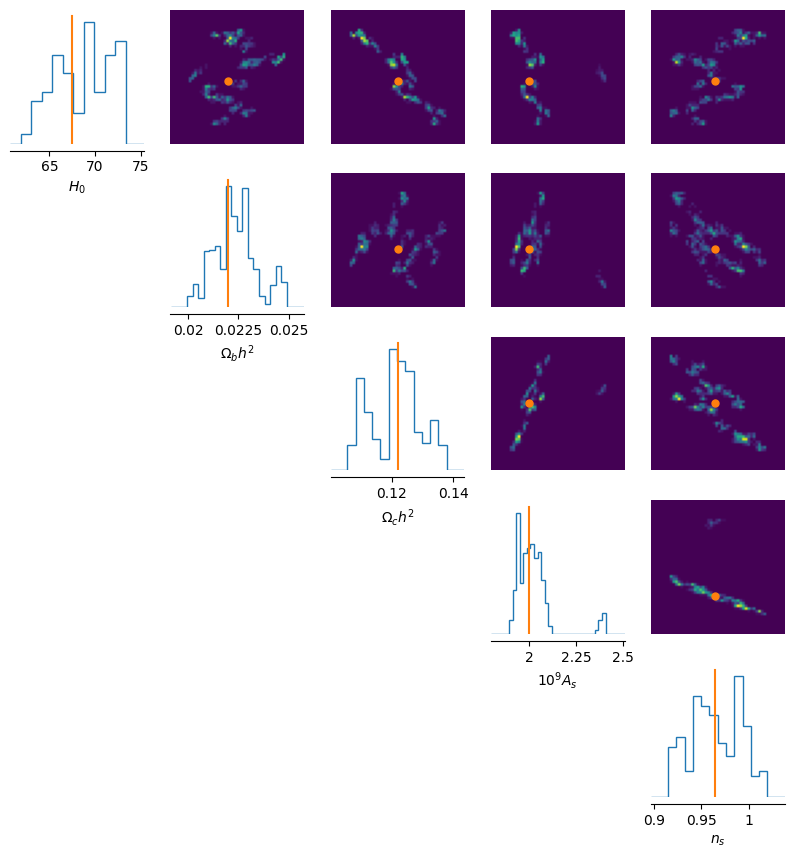

In [11]:
samples2, posterior2_mcmc, posterior2_direct, inference2 = train_net_generate_samples(
    x_train_2, theta, x_obs_2, prior, verbose=True, max_epoch=1000, true_val=theta_true
)

##### In future add some posterior checks here

#### Saving Results

In [12]:
results = {
    "samples1":          samples1,          # posterior samples (N, 5) — null split
    "samples2":          samples2,          # posterior samples (N, 5) — systematic split
    "posterior1_mcmc":   posterior1_mcmc,
    "posterior1_direct": posterior1_direct,
    "posterior2_mcmc":   posterior2_mcmc,
    "posterior2_direct": posterior2_direct,
    "inference1":        inference1,        # NPE trained on beam_base
    "inference2":        inference2,        # NPE trained on amplitude_systematic
    "prior":             prior,
    "theta":             theta,             # training theta (N, 5)
    "x_train_1":         x_train_1,         # training summaries, null beam
    "x_train_2":         x_train_2,         # training summaries, amplitude systematic
    "x_obs_1":           x_obs_1,           # observed summary, null beam
    "x_obs_2":           x_obs_2,           # observed summary, amplitude systematic
    "nl_base":           nl_base,           # noise spectrum (consistent throughout)
    "beam_base":              beam_base,              # beam FWHM in arcmin (fixed for both splits)
    "amplitude_null":         amplitude_null,         # no systematic (=1.0)
    "amplitude_systematic":   amplitude_systematic,   # calibration uncertainty scale factor
    "TRUE_SEED_CMB":     TRUE_SEED_CMB,
    "TRUE_SEED_NOISE":   TRUE_SEED_NOISE,
    # Compressor saved as arrays — reconstruct with make_compressor() after loading
    "fiducial":          fiducial,          # fiducial C_ell spectrum (numpy)
    "cov":               cov,               # diagonal covariance (numpy)
    "derivs":            derivs,            # MOPED derivative vectors (numpy)
    "theta_true":        theta_true,        # fiducial cosmology (5,)
    "unique_seeds":      unique_seeds,
}

fname = "cmb_test_calibration_uncertainty_point1.pt"
torch.save(results, fname)


/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/torch/serialization.py:1088: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tensorboard summary writer (instead of appending to the current one).
  pickler.dump(obj)


### KL Section

#### Load Results

In [6]:
def load_results_file(file_name):
    res = torch.load(file_name)
    return res

def extract_results(res):
    """
    Given a loaded results dict, return a tuple in a fixed order.
    This is explicit and avoids surprises.
    """
    keys = [
        "samples1", "samples2",
        "posterior1_mcmc", "posterior1_direct",
        "posterior2_mcmc", "posterior2_direct",
        "inference1", "inference2",
        "prior",
        "theta",
        "x_train_1", "x_train_2",
        "x_obs_1", "x_obs_2",
        "nl_base",
        "beam_base", "amplitude_null", "amplitude_systematic",
        "TRUE_SEED_CMB", "TRUE_SEED_NOISE",
        "fiducial", "cov", "derivs",
        "theta_true", "unique_seeds",
    ]

    missing = [k for k in keys if k not in res]
    if missing:
        raise KeyError(f"Missing keys in results dict: {missing}")

    return tuple(res[k] for k in keys)


In [7]:
fname = "cmb_test_calibration_uncertainty_point1.pt"

res = load_results_file(fname)

(samples1, samples2,
 posterior1_mcmc, posterior1_direct,
 posterior2_mcmc, posterior2_direct,
 inference1, inference2,
 prior,
 theta,
 x_train_1, x_train_2,
 x_obs_1, x_obs_2,
 nl_base,
 beam_base, amplitude_null, amplitude_systematic,
 TRUE_SEED_CMB, TRUE_SEED_NOISE,
 fiducial, cov, derivs,
 theta_true, unique_seeds,
) = extract_results(res)

# Reconstruct the compressor closure from its saved arrays
my_compressor = make_compressor(fiducial, cov, derivs)


/tmp/ipykernel_3765/2364949401.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  res = torch.load(file_name)


In [8]:
# ### After April 9 Meeting — Diagnostic plots ###
# Resample with many more draws using the direct (i.i.d.) sampler.
# The saved MCMC samples (1,000) are too few for clean 5D marginals.
samples1 = posterior1_direct.sample((100_000,), x=x_obs_1)
samples2 = posterior2_direct.sample((100_000,), x=x_obs_2)
print(f"Resampled: {samples1.shape[0]} null, {samples2.shape[0]} systematic")


  0%|          | 0/100000 [00:00<?, ?it/s]

/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2190.)
  outputs, _ = torch.triangular_solve(


  0%|          | 0/100000 [00:00<?, ?it/s]

Resampled: 100000 null, 100000 systematic


#### After April 9 Meeting:


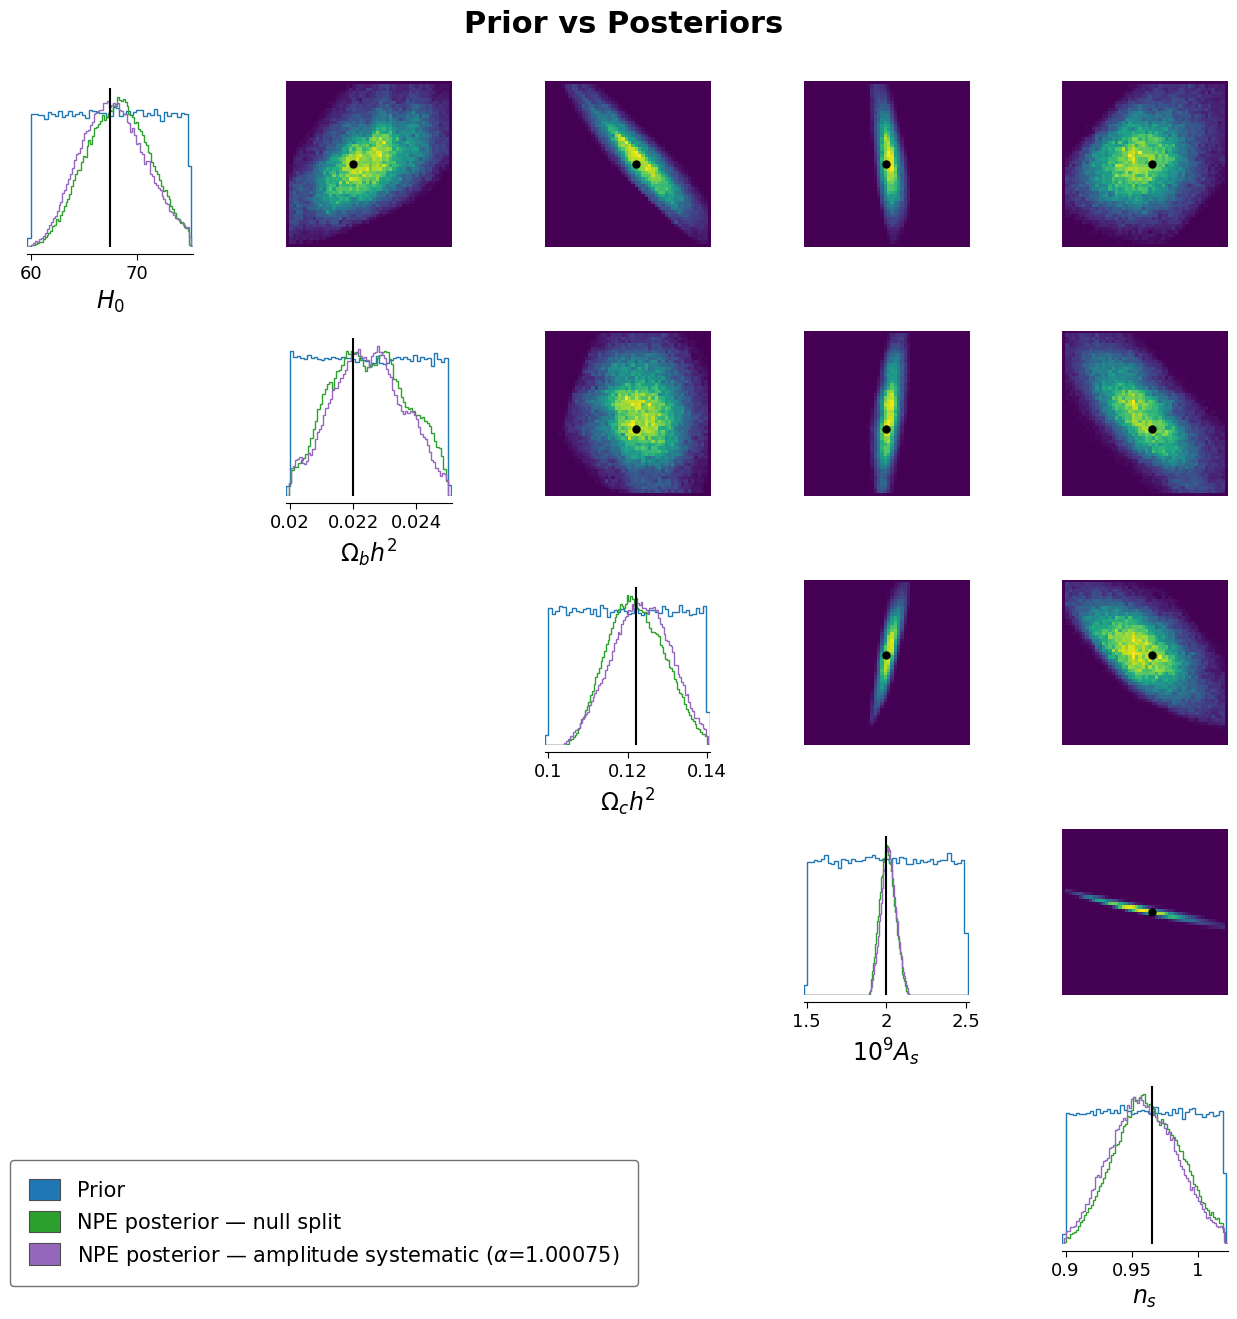

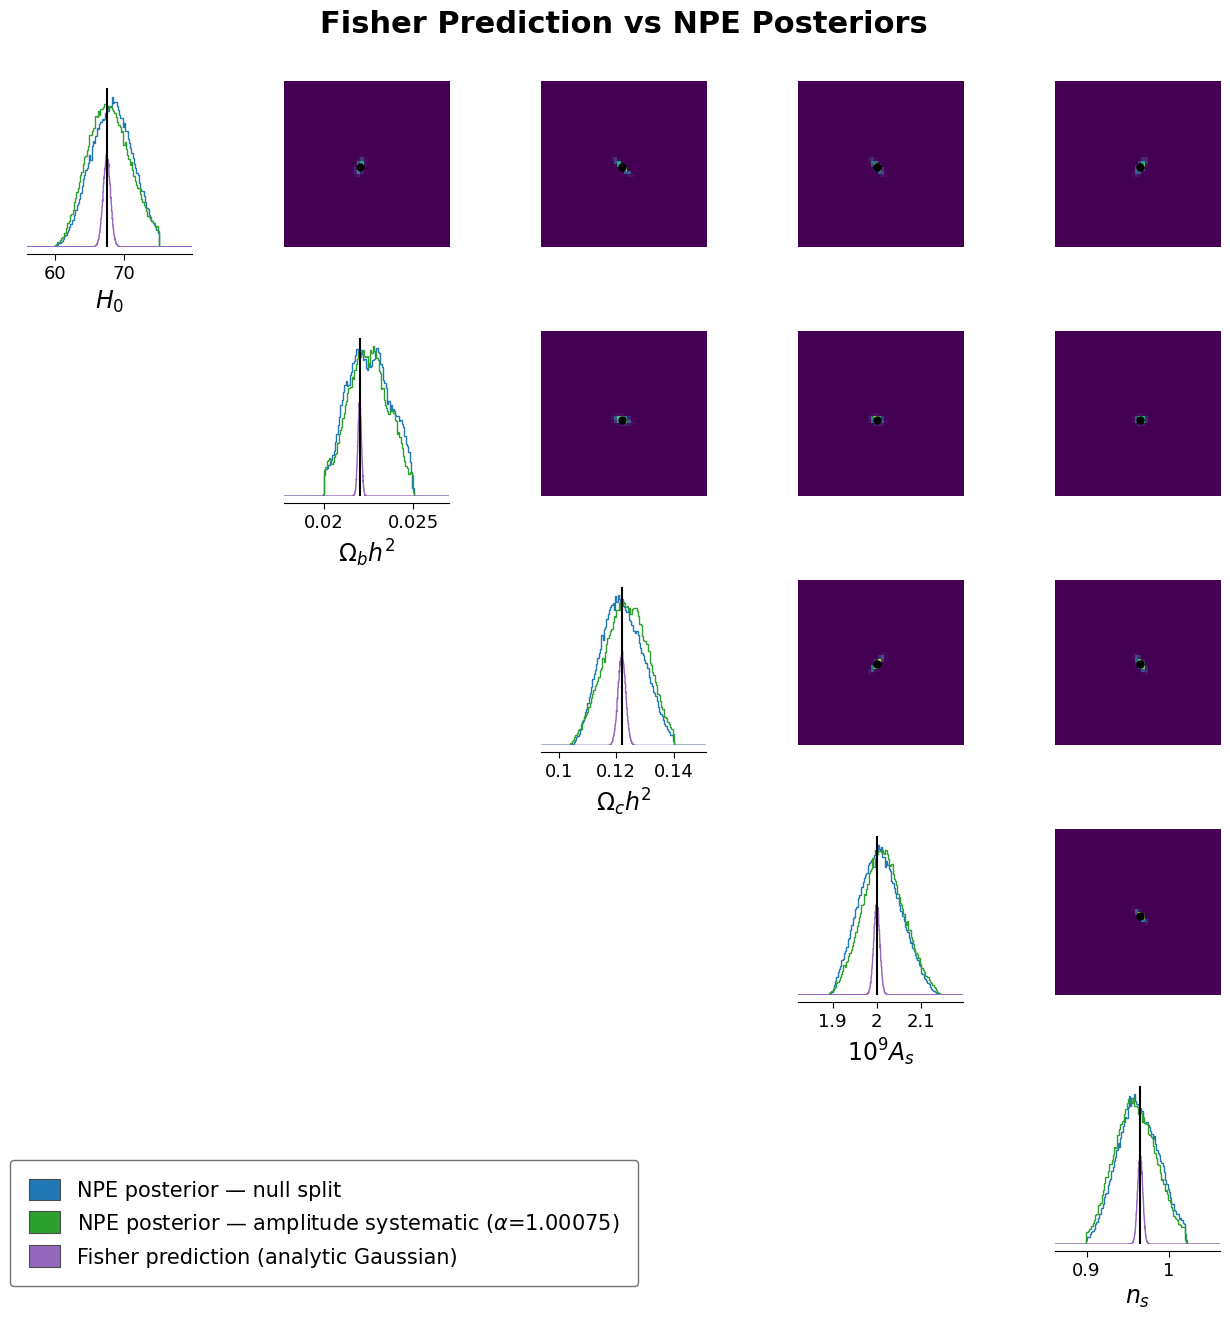


Parameter 1σ widths  (A_s in units of 10^9 A_s):
Parameter                Fisher σ   NPE σ (null)   NPE σ (sys)
───────────────────────────────────────────────────────────────
$H_0$                       0.529            2.9         2.978
$\Omega_b h^2$          0.0001024       0.001155      0.001101
$\Omega_c h^2$           0.001312       0.006984      0.007208
$10^9 A_s$               0.006863        0.04614       0.04608
$n_s$                    0.003143        0.02458       0.02484


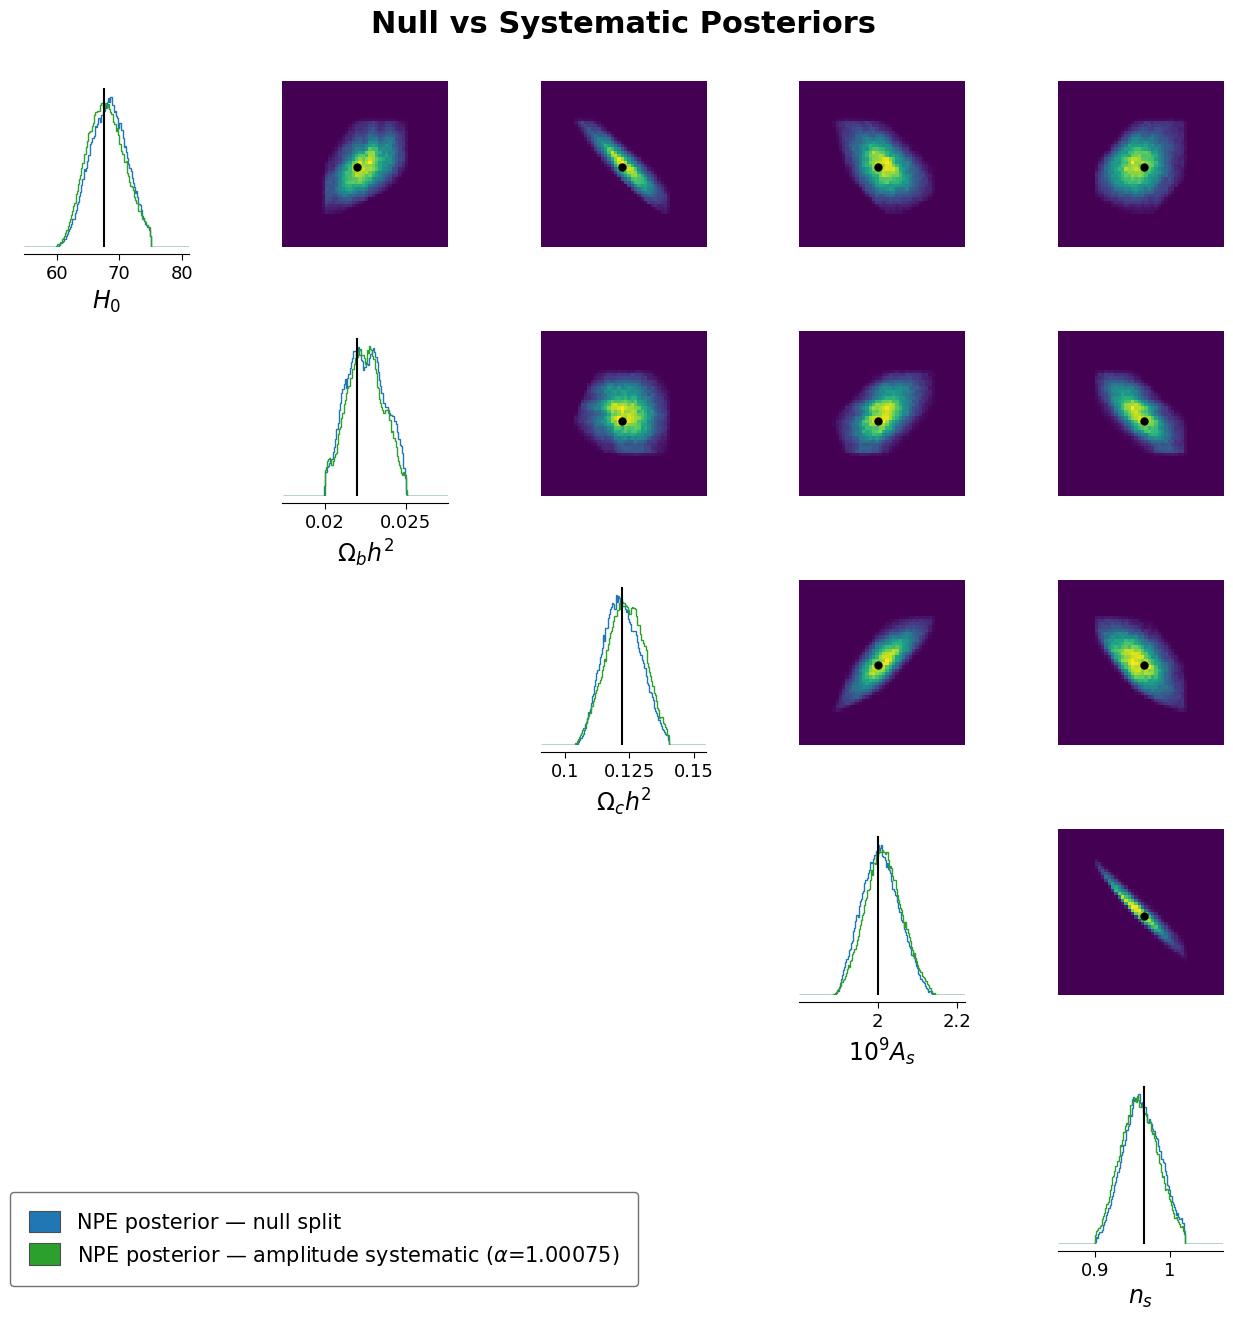

In [9]:
# ============================================================
# After April 9 Meeting — Prior/Posterior diagnostic plots
#
# Will's asks:
#   Plot 1: Prior vs both posteriors   (how much is learned?)
#   Plot 2: Fisher prediction vs both posteriors  (NPE validation)
#   Plot 3: Null vs systematic posteriors only
#
# Adapted from the beam-miscalibration notebook. Two differences from that
# version:
#   - Systematic is the amplitude (calibration) scale `amplitude_systematic`,
#     not a beam FWHM.
#   - This notebook uses a BoxUniform prior rather than a MultivariateNormal,
#     so limits come from empirical min/max of prior samples and the Fisher
#     posterior falls back to diag(prior.variance) when covariance_matrix is
#     absent.
# ============================================================

import matplotlib as mpl
import matplotlib.patches as mpatches
from torch.distributions import MultivariateNormal

_RC = {
    "font.size":       16,
    "axes.labelsize":  18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.titlesize":  16,
}

PARAM_LABELS = [
    r"$H_0$",
    r"$\Omega_b h^2$",
    r"$\Omega_c h^2$",
    r"$10^9 A_s$",
    r"$n_s$",
]


def _style_axes(axes):
    """Enforce presentation-quality font sizes on sbi.pairplot axes."""
    for row in axes:
        for ax in row:
            if ax is None:
                continue
            ax.tick_params(axis="both", labelsize=13, length=4, width=0.8)
            ax.xaxis.label.set_size(17)
            ax.yaxis.label.set_size(17)
            for spine in ax.spines.values():
                spine.set_linewidth(0.8)


def _add_legend(fig, entries):
    """Figure-level legend in the bottom-left corner."""
    handles = [mpatches.Patch(facecolor=c, edgecolor="0.3", linewidth=0.8, label=lbl)
               for c, lbl in entries]
    leg = fig.legend(
        handles=handles, fontsize=15, frameon=True,
        facecolor="white", edgecolor="0.3",
        loc="lower left", bbox_to_anchor=(0.02, 0.02),
        borderpad=0.9, handlelength=1.5, handleheight=1.2,
    )
    leg.get_frame().set_linewidth(1.0)


def _scale_As(s):
    """Return a float32 tensor with A_s (col 3) scaled by 1e9 for display."""
    if not torch.is_tensor(s):
        s = torch.tensor(np.asarray(s, dtype=np.float32))
    s = s.clone().float()
    s[:, 3] = s[:, 3] * 1e9
    return s


def _prior_limits_from_samples(prior_samples_display, pad_frac=0.02):
    """Empirical min/max of prior samples (display units) with a small pad.
    Works for any prior type. Input is (N,5) with A_s already scaled."""
    arr = prior_samples_display.numpy() if torch.is_tensor(prior_samples_display) \
          else np.asarray(prior_samples_display, dtype=float)
    mn, mx = arr.min(axis=0), arr.max(axis=0)
    pad    = pad_frac * (mx - mn)
    return [[mn[i] - pad[i], mx[i] + pad[i]] for i in range(5)]


def _sys_label(amplitude_systematic):
    if amplitude_systematic is not None:
        return f"NPE posterior — amplitude systematic ($\\alpha$={amplitude_systematic:.5f})"
    return "NPE posterior — systematic split"


def compute_fisher_posterior(derivs, cov, prior):
    """MOPED Fisher matrix  F = derivs @ diag(1/cov) @ derivs.T   shape (5,5)
    Posterior covariance  C_post = (F + C_prior^{-1})^{-1}.
    Falls back to diag(prior.variance) when prior has no covariance_matrix
    (e.g. BoxUniform — treats uniform as a moment-matched Gaussian)."""
    F = (derivs / cov) @ derivs.T
    try:
        prior_cov = np.asarray(prior.covariance_matrix, dtype=float)
    except AttributeError:
        prior_cov = np.diag(np.asarray(prior.variance, dtype=float))
    C_prior_inv = np.linalg.inv(prior_cov)
    C_post      = np.linalg.inv(F + C_prior_inv)
    return F, C_post


def plot_prior_vs_posteriors(samples1, samples2, prior, theta_true,
                              amplitude_systematic=None, n_prior_samples=100_000):
    """Shows how much the posteriors shrink relative to the prior."""
    prior_samples = prior.sample((n_prior_samples,))
    prior_plot    = _scale_As(prior_samples)
    post1_plot    = _scale_As(samples1)
    post2_plot    = _scale_As(samples2)

    theta_true_plot    = np.asarray(theta_true, dtype=float).copy()
    theta_true_plot[3] = theta_true_plot[3] * 1e9

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[prior_plot, post1_plot, post2_plot],
            points=torch.tensor(theta_true_plot, dtype=torch.float32)[None, :],
            limits=_prior_limits_from_samples(prior_plot),
            figsize=(13, 13),
            labels=PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "Prior"),
        ("#2ca02c", "NPE posterior — null split"),
        ("#9467bd", _sys_label(amplitude_systematic)),
    ])
    fig.suptitle("Prior vs Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_fisher_vs_posteriors(samples1, samples2, prior, theta_true,
                               derivs, cov, amplitude_systematic=None,
                               n_fisher_samples=50_000):
    """Compares analytic Fisher prediction against both NPE posteriors."""
    F, C_post = compute_fisher_posterior(derivs, cov, prior)

    theta_true_np  = np.asarray(theta_true, dtype=float)
    fisher_dist    = MultivariateNormal(
        loc=torch.tensor(theta_true_np, dtype=torch.float32),
        covariance_matrix=torch.tensor(C_post, dtype=torch.float32),
    )
    fisher_samples = fisher_dist.sample((n_fisher_samples,))

    post1_plot  = _scale_As(samples1)
    post2_plot  = _scale_As(samples2)
    fisher_plot = _scale_As(fisher_samples)

    theta_true_plot    = theta_true_np.copy()
    theta_true_plot[3] = theta_true_plot[3] * 1e9

    # Tight limits: ±4.5σ around the combined cloud
    all_np = np.concatenate([post1_plot.numpy(), post2_plot.numpy(),
                              fisher_plot.numpy()], axis=0)
    means  = all_np.mean(axis=0)
    stds   = all_np.std(axis=0)
    tight_limits = [[means[i] - 4.5*stds[i], means[i] + 4.5*stds[i]] for i in range(5)]

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[post1_plot, post2_plot, fisher_plot],
            points=torch.tensor(theta_true_plot, dtype=torch.float32)[None, :],
            limits=tight_limits,
            figsize=(13, 13),
            labels=PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "NPE posterior — null split"),
        ("#2ca02c", _sys_label(amplitude_systematic)),
        ("#9467bd", "Fisher prediction (analytic Gaussian)"),
    ])
    fig.suptitle("Fisher Prediction vs NPE Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    print("\nParameter 1σ widths  (A_s in units of 10^9 A_s):")
    print(f"{'Parameter':<20} {'Fisher σ':>12} {'NPE σ (null)':>14} {'NPE σ (sys)':>13}")
    print("─" * 63)
    fisher_stds = np.sqrt(np.diag(C_post))
    npe1_stds   = post1_plot.numpy().std(axis=0)
    npe2_stds   = post2_plot.numpy().std(axis=0)
    for i, lbl in enumerate(PARAM_LABELS):
        f_s = fisher_stds[i] * (1e9 if i == 3 else 1.0)
        print(f"{lbl:<20} {f_s:>12.4g} {npe1_stds[i]:>14.4g} {npe2_stds[i]:>13.4g}")

    return F, C_post


def plot_posteriors_overlaid(samples1, samples2, prior, theta_true,
                              amplitude_systematic=None):
    """Just the two posteriors, tight limits."""
    post1_plot = _scale_As(samples1)
    post2_plot = _scale_As(samples2)

    theta_true_plot    = np.asarray(theta_true, dtype=float).copy()
    theta_true_plot[3] = theta_true_plot[3] * 1e9

    all_np = np.concatenate([post1_plot.numpy(), post2_plot.numpy()], axis=0)
    means  = all_np.mean(axis=0)
    stds   = all_np.std(axis=0)
    tight_limits = [[means[i] - 4.5*stds[i], means[i] + 4.5*stds[i]] for i in range(5)]

    with mpl.rc_context(_RC):
        fig, axes = pairplot(
            samples=[post1_plot, post2_plot],
            points=torch.tensor(theta_true_plot, dtype=torch.float32)[None, :],
            limits=tight_limits,
            figsize=(13, 13),
            labels=PARAM_LABELS,
            fig_kwargs={"points_colors": ["black"], "legend": False},
        )

    _style_axes(axes)
    _add_legend(fig, [
        ("#1f77b4", "NPE posterior — null split"),
        ("#2ca02c", _sys_label(amplitude_systematic)),
    ])
    fig.suptitle("Null vs Systematic Posteriors", fontsize=22, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# --- Run ---
plot_prior_vs_posteriors(
    samples1, samples2, prior, theta_true,
    amplitude_systematic=amplitude_systematic,
)

F, C_post = plot_fisher_vs_posteriors(
    samples1, samples2, prior, theta_true, derivs, cov,
    amplitude_systematic=amplitude_systematic,
)

plot_posteriors_overlaid(
    samples1, samples2, prior, theta_true,
    amplitude_systematic=amplitude_systematic,
)


Removed no burn in
Removed no burn in
Removed no burn in


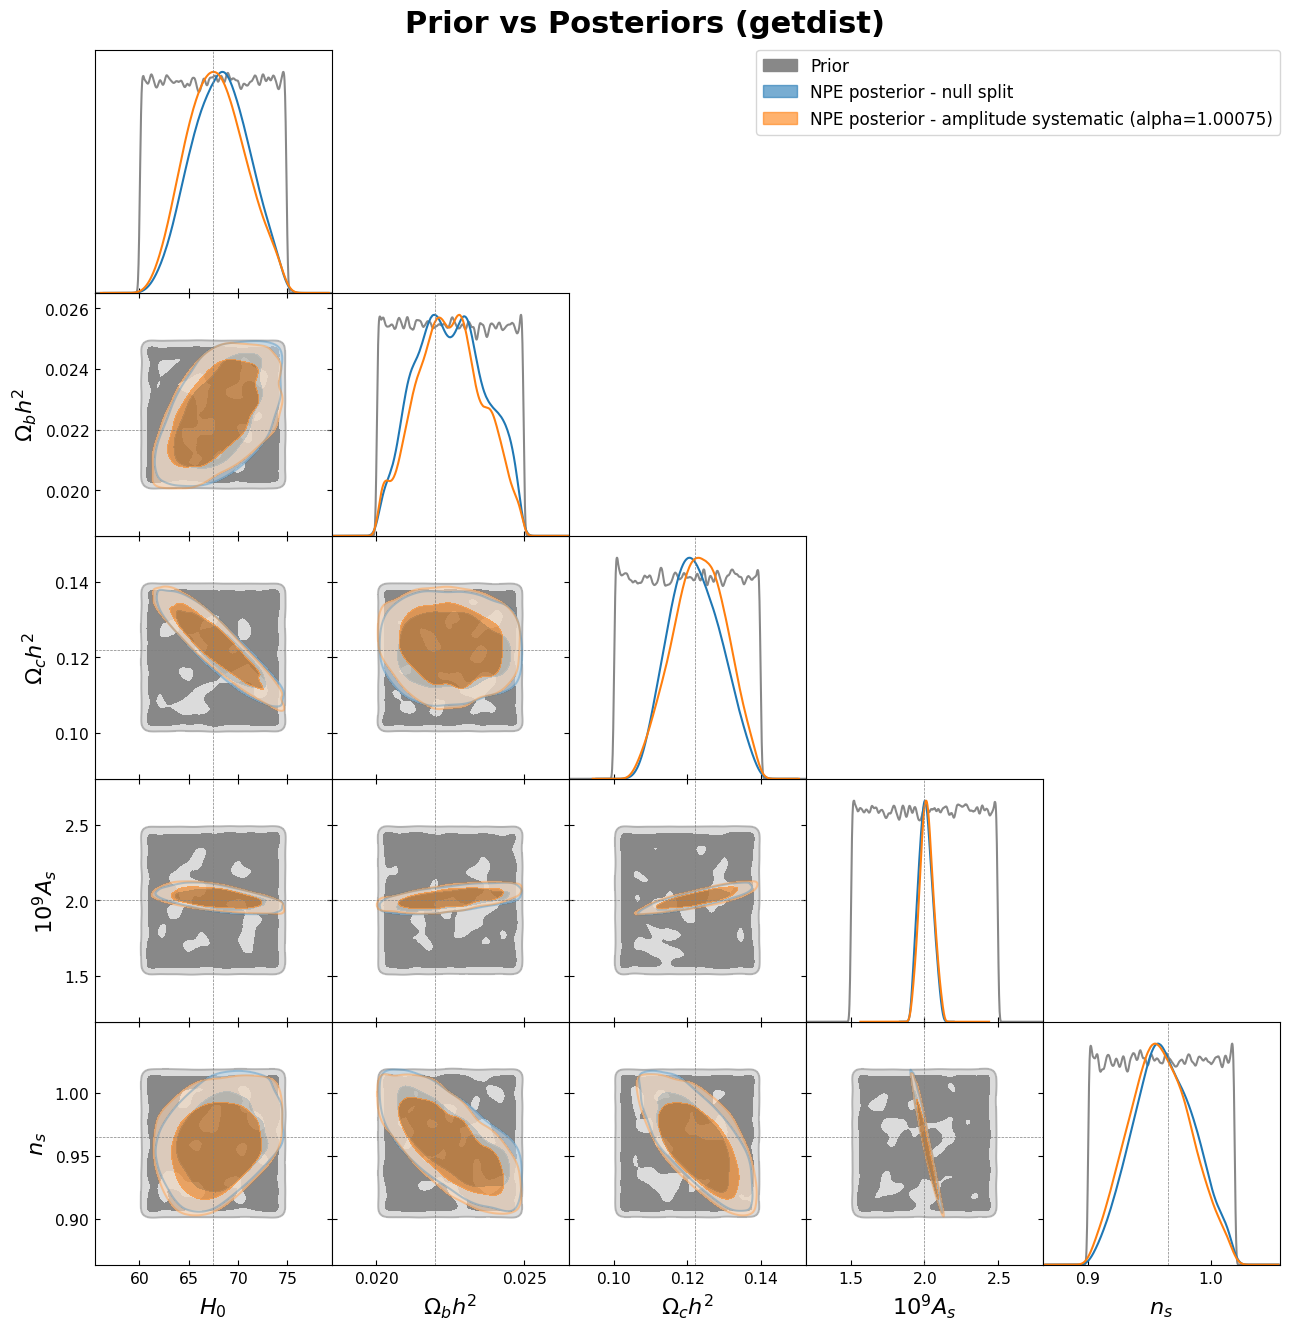

Removed no burn in
Removed no burn in
Removed no burn in


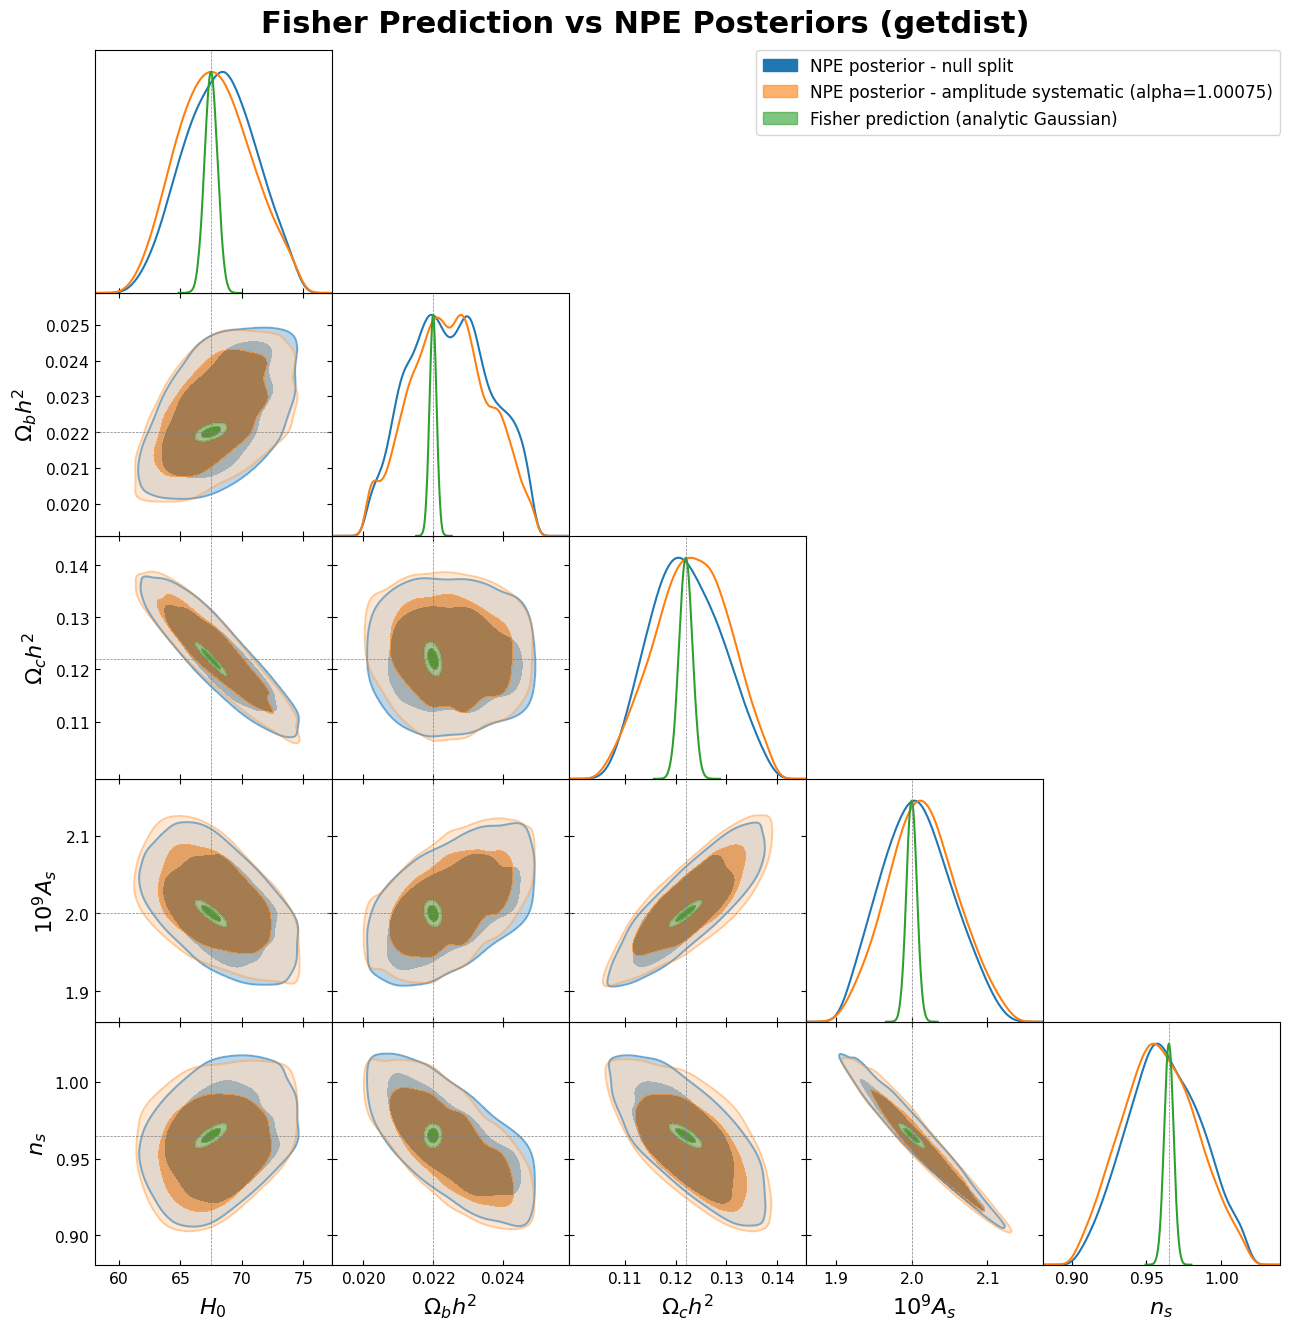

Removed no burn in
Removed no burn in


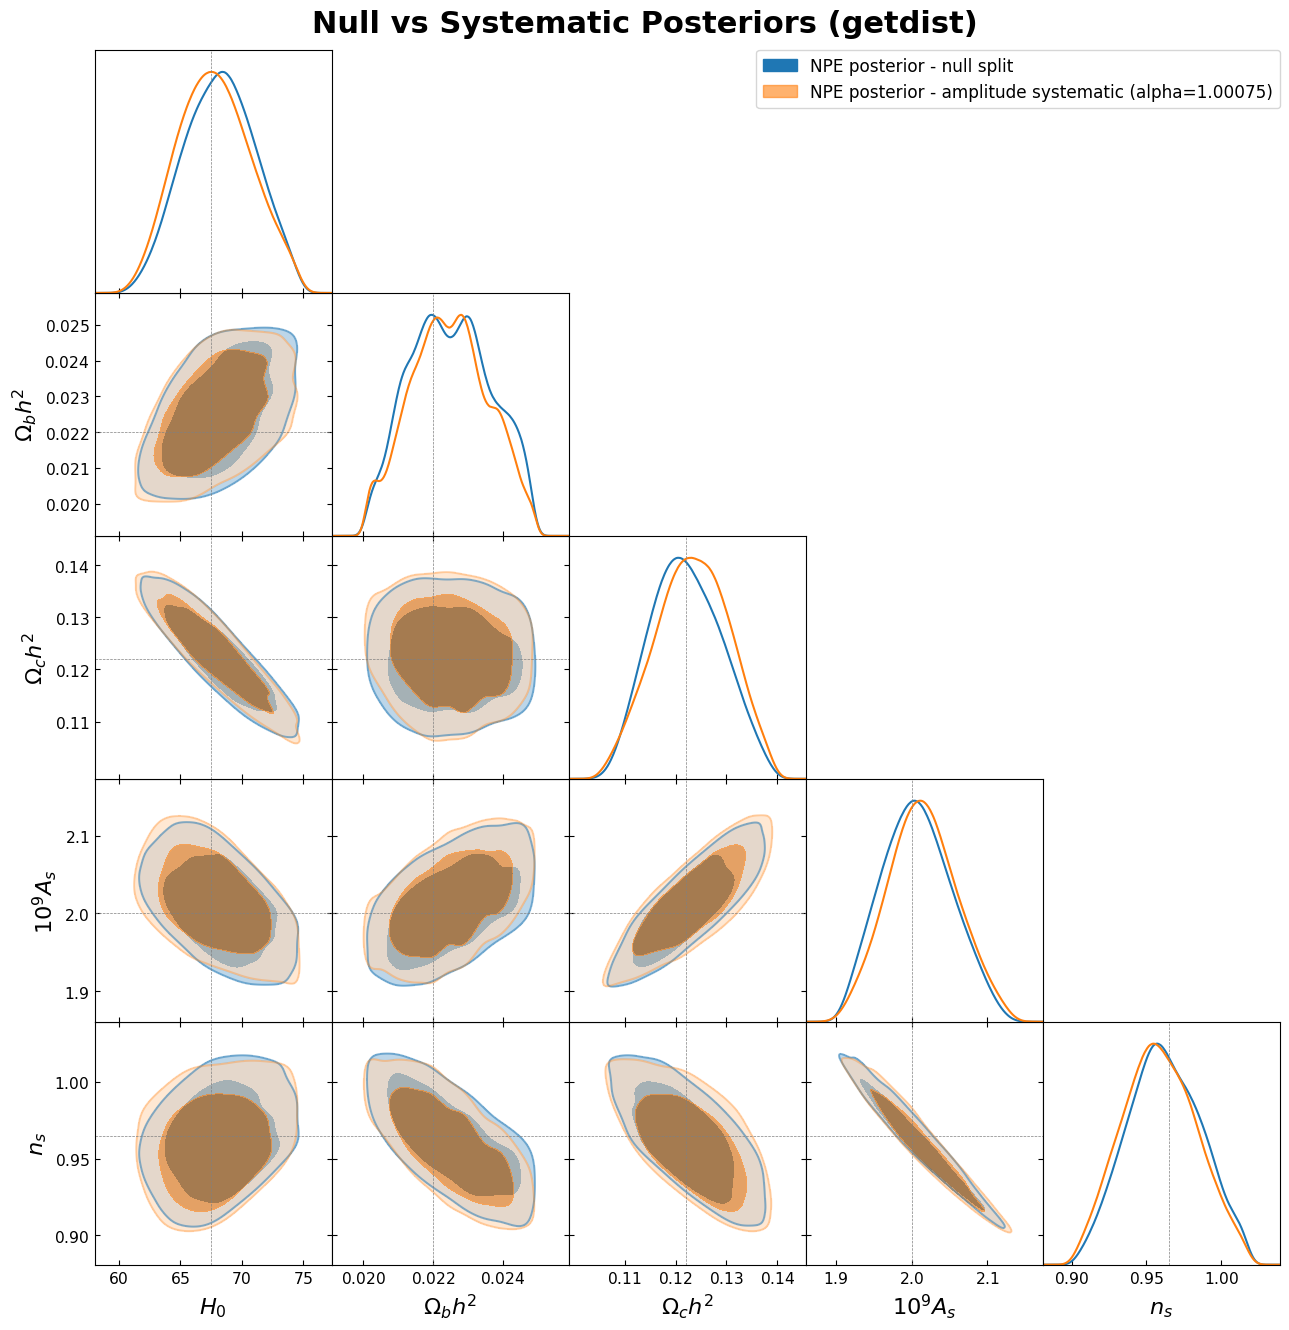

In [10]:
# ============================================================
# getdist versions of the three diagnostic plots
# (Will's Apr-14 suggestion to use getdist/corner over sbi.pairplot)
# ============================================================

# Install getdist on first run (comment out after)
#%pip install --quiet getdist

from getdist import MCSamples, plots as gd_plots

GD_NAMES  = ["H0", "ombh2", "omch2", "As_scaled", "ns"]
GD_LABELS = ["H_0", r"\Omega_b h^2", r"\Omega_c h^2", r"10^9 A_s", "n_s"]


def _to_mcsamples(samples, label):
    """Convert a (N,5) tensor/array to MCSamples with A_s scaled by 1e9."""
    arr = samples.numpy() if torch.is_tensor(samples) else np.asarray(samples)
    arr = arr.astype(float).copy()
    arr[:, 3] *= 1e9
    return MCSamples(samples=arr, names=GD_NAMES, labels=GD_LABELS, label=label)


def _make_plotter(width_inch=13):
    g = gd_plots.get_subplot_plotter(width_inch=width_inch)
    # Peak=1 normalisation for 1D marginals (Will's request — shape comparison
    # without sample-count bias)
    g.settings.norm_1d_density          = True
    g.settings.alpha_filled_add         = 0.6
    g.settings.axes_fontsize            = 13
    g.settings.lab_fontsize             = 18
    g.settings.legend_fontsize          = 14
    g.settings.linewidth                = 2.0
    g.settings.linewidth_contour        = 2.0
    g.settings.solid_contour_palefactor = 0.7
    return g


def _theta_true_markers(theta_true):
    t = np.asarray(theta_true, dtype=float).copy()
    t[3] *= 1e9
    return dict(zip(GD_NAMES, t))


def _sys_label_gd(amplitude_systematic):
    if amplitude_systematic is not None:
        return f"NPE posterior - amplitude systematic (alpha={amplitude_systematic:.5f})"
    return "NPE posterior - systematic split"


def plot_prior_vs_posteriors_gd(samples1, samples2, prior, theta_true,
                                 amplitude_systematic=None, n_prior_samples=100_000):
    mc_prior = _to_mcsamples(prior.sample((n_prior_samples,)), "Prior")
    mc_null  = _to_mcsamples(samples1, "NPE posterior - null split")
    mc_sys   = _to_mcsamples(samples2, _sys_label_gd(amplitude_systematic))

    g = _make_plotter()
    g.triangle_plot(
        [mc_prior, mc_null, mc_sys],
        filled=True,
        contour_colors=["#888888", "#1f77b4", "#ff7f0e"],
        markers=_theta_true_markers(theta_true),
        legend_loc="upper right",
    )
    plt.suptitle("Prior vs Posteriors (getdist)", fontsize=22, fontweight="bold", y=1.02)
    plt.show()


def plot_fisher_vs_posteriors_gd(samples1, samples2, prior, theta_true,
                                  derivs, cov, amplitude_systematic=None,
                                  n_fisher_samples=50_000):
    F, C_post = compute_fisher_posterior(derivs, cov, prior)

    theta_np  = np.asarray(theta_true, dtype=float)
    fisher_dist = MultivariateNormal(
        loc=torch.tensor(theta_np, dtype=torch.float32),
        covariance_matrix=torch.tensor(C_post, dtype=torch.float32),
    )
    fisher_samples = fisher_dist.sample((n_fisher_samples,))

    mc_null   = _to_mcsamples(samples1,       "NPE posterior - null split")
    mc_sys    = _to_mcsamples(samples2,       _sys_label_gd(amplitude_systematic))
    mc_fisher = _to_mcsamples(fisher_samples, "Fisher prediction (analytic Gaussian)")

    g = _make_plotter()
    g.triangle_plot(
        [mc_null, mc_sys, mc_fisher],
        filled=True,
        contour_colors=["#1f77b4", "#ff7f0e", "#2ca02c"],
        markers=_theta_true_markers(theta_true),
        legend_loc="upper right",
    )
    plt.suptitle("Fisher Prediction vs NPE Posteriors (getdist)",
                 fontsize=22, fontweight="bold", y=1.02)
    plt.show()
    return F, C_post


def plot_posteriors_overlaid_gd(samples1, samples2, prior, theta_true,
                                 amplitude_systematic=None):
    mc_null = _to_mcsamples(samples1, "NPE posterior - null split")
    mc_sys  = _to_mcsamples(samples2, _sys_label_gd(amplitude_systematic))

    g = _make_plotter()
    g.triangle_plot(
        [mc_null, mc_sys],
        filled=True,
        contour_colors=["#1f77b4", "#ff7f0e"],
        markers=_theta_true_markers(theta_true),
        legend_loc="upper right",
    )
    plt.suptitle("Null vs Systematic Posteriors (getdist)",
                 fontsize=22, fontweight="bold", y=1.02)
    plt.show()


# --- Run ---
plot_prior_vs_posteriors_gd(
    samples1, samples2, prior, theta_true,
    amplitude_systematic=amplitude_systematic,
)
_ = plot_fisher_vs_posteriors_gd(
    samples1, samples2, prior, theta_true, derivs, cov,
    amplitude_systematic=amplitude_systematic,
)
plot_posteriors_overlaid_gd(
    samples1, samples2, prior, theta_true,
    amplitude_systematic=amplitude_systematic,
)


#### Plot posteriors overlayed

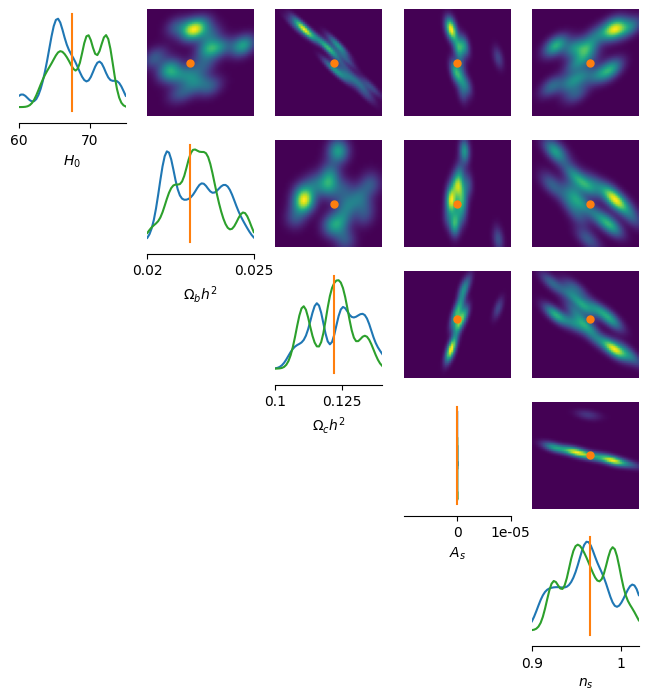

In [15]:
param_labels = [
    r"$H_0$",
    r"$\Omega_b h^2$",
    r"$\Omega_c h^2$",
    r"$A_s$",
    r"$n_s$",
]

# Use prior bounds as plot limits for a clean, comparable view of both posteriors
limits = [
    [60.0,   75.0  ],
    [0.020,  0.025 ],
    [0.10,   0.14  ],
    [1.5e-9, 2.5e-9],
    [0.90,   1.02  ],
]

_ = pairplot(
    samples=[samples1, samples2],
    points=theta_true,
    limits=limits,
    upper="kde",
    diag="kde",
    figsize=(8, 8),
    labels=param_labels,
)

#### Define and calculate KL

In [16]:
def calc_dkl(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        z = log_post1 - log_post2
        mean = z.mean().item()
        std_dev = z.std(unbiased = True).item()
        error = std_dev/np.sqrt(n_theta)

        return mean, std_dev, error


def calibrate_null_dkl(null_posterior, prior, N, n_theta, compressor, nl_null, beam_null, dkl_obs):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same CMB sky (seed_cmb=i), independent noise draws (seed_noise offset by 1M)
        # Both splits use the null beam — true null, no systematic
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 2_000_000) #obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    #plot histogram
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=1, label='Observed D_KL Value')
    plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=1, label='95% Critical Value')
    plt.ylabel("density")
    plt.title(r"Null calibration of $D_{KL}$ (data realisations under null)")
    plt.legend()
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


/data/vault/jv447/venvs/research-project/lib/python3.11/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2190.)
  outputs, _ = torch.triangular_solve(


0/100
20/100
40/100
60/100
80/100


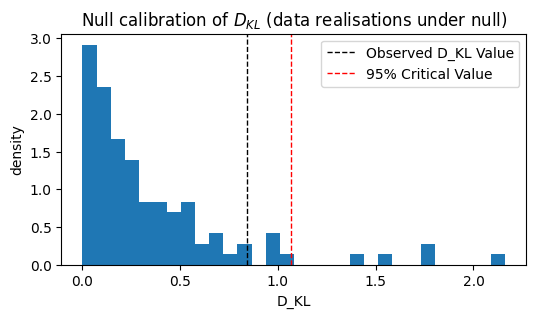

Null 95 percent critical value: 1.0673306107521046
DKL observed: 0.8430776000022888


In [17]:
dkl_obs, std_obs, error_obs = calc_dkl(posterior1_direct, posterior2_direct, x_obs_1, x_obs_2, n_theta=500)


dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, prior, 100, 500, my_compressor, nl_base, beam_base, dkl_obs)
print("DKL observed:", dkl_obs)


In [20]:
def calibrate_null_dkl_neat(null_posterior, prior, N, n_theta, compressor, nl_null, beam_null, dkl_obs):
    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 50 == 0:
            print(f"{i}/{N}")

        # obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same CMB sky (seed_cmb=i), independent noise draws (seed_noise offset by 1M)
        # Both splits use the null beam — true null, no systematic
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 2_000_000) # obtaining summary statistics of data

        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    # ==========================================
    # PLOTTING
    # ==========================================
    # Larger figure size and high DPI for crisp projection
    plt.figure(figsize=(8, 4.5), dpi=150)
    
    # Add a clean grid *behind* the histogram bars
    plt.gca().set_axisbelow(True)
    plt.grid(axis='y', linestyle='--', alpha=0.7) 
    plt.grid(axis='x', linestyle=':', alpha=0.4)  

    # Original style: solid bars, no gaps
    plt.hist(dkls, bins=30, density=True, color='tab:blue', label=r'Null Distribution ($H_0$)')
    
    # Vertical lines
    plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Observed $D_{{KL}}$ ({dkl_obs:.2f})')
    plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
                label=f'95% Critical Value ({crit_val_95:.2f})')
    
    # Labels and Titles
    plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
    plt.ylabel("Probability Density", fontsize=14, labelpad=10)
    plt.title(r"Null Calibration of $D_{KL}$", fontsize=16, pad=15)
    
    # Tick marks: larger fonts
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Upgraded Legend
    plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)
    
    plt.tight_layout()
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


0/200
50/200
100/200
150/200


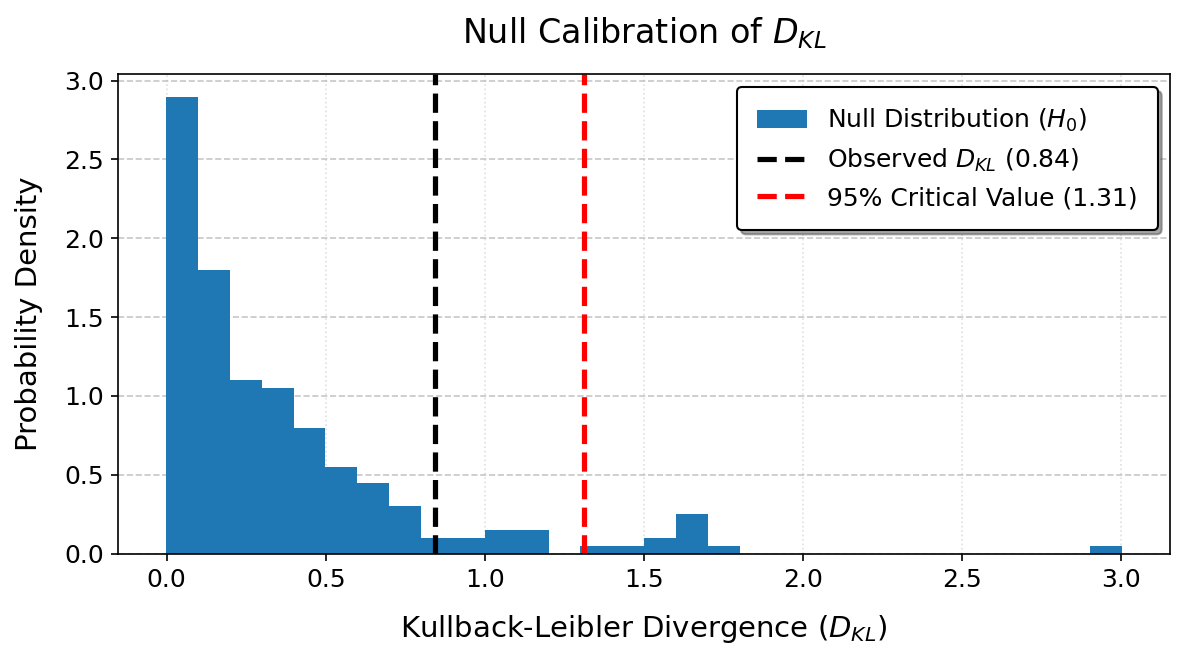

Null 95 percent critical value: 1.312340974807737
DKL observed: 0.8430776000022888


In [21]:
dkls_neat, crit_val_95_neat = calibrate_null_dkl_neat(posterior1_direct, prior, 200, 500, my_compressor, nl_base, beam_base, dkl_obs)
print("DKL observed:", dkl_obs)


#### Perturbation Calc

In [ ]:
def calibrate_null_dkl_and_perturbed(null_posterior, prior, N, n_theta, compressor, nl_null, beam_null, amplitude_perturbed):
    """
    Calibration uncertainty systematic: amplitude_perturbed scales the C_ell in split 1.
    amplitude_perturbed=1.0 → null; >1.0 → calibration uncertainty systematic.
    """
    dkls = np.zeros(N) # to store dkls
    dkls_perturbed  = np.zeros(N)
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same CMB sky, independent noise draws for the two null splits (no systematic)
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 amplitude_scale=1.0)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 2_000_000,
                                 amplitude_scale=1.0)
        # Perturbed split 1: same sky & noise seed as x1_i, only amplitude changes
        x1_i_perturbed = blanket_simulator(theta_i, compressor, nl_null,
                                           beam_fwhm=beam_null,
                                           seed_cmb=i, seed_noise=i + 1_000_000,
                                           amplitude_scale=amplitude_perturbed)
      
        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

        dkls_perturbed[i], std_dev2, error2 = calc_dkl(null_posterior, null_posterior, x1_i_perturbed, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))
    median_perturbed = float(np.median(dkls_perturbed))
    
    #plot histograms
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title(r"Null calibration of $D_{KL}$ (data realisations under null)")
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.hist(dkls_perturbed, bins=30, density=True)
    plt.axvline(median_perturbed, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Median Perturbed ({median_perturbed:.2f})')
    plt.xlabel("D_KL")
    plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)
    plt.ylabel("density")
    plt.title(r"Perturbed calibration of $D_{KL}$ (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)
    print("Perturbed 95 percent critical value:", crit_val_95_perturbed)

    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed


####  looping through shifts to find sensitivity 

In [24]:
def calibrate_null_dkl_and_perturb_mean(null_posterior, prior, N, n_theta, compressor, nl_null, beam_null, multiplier):
    """
    Calibration uncertainty systematic: the amplitude multiplier scales the observed
    C_ell in split 1, leaving split 2 (and training) unaffected.
    multiplier=1.0 → null; multiplier>1.0 → calibration uncertainty systematic.
    """
    # Amplitude scale for the perturbed split (calibration uncertainty)
    amplitude_perturbed = multiplier

    dkls = np.zeros(N) # to store dkls
    dkls_perturbed  = np.zeros(N)
    for i in range(N):
        if i % 50 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

        # Same CMB sky, independent noise draws for the two null splits (no systematic)
        x1_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 1_000_000,
                                 amplitude_scale=1.0)
        x2_i = blanket_simulator(theta_i, compressor, nl_null,
                                 beam_fwhm=beam_null,
                                 seed_cmb=i, seed_noise=i + 2_000_000,
                                 amplitude_scale=1.0)
        # Perturbed split 1: same sky & noise seed as x1_i, only amplitude changes
        x1_i_perturbed = blanket_simulator(theta_i, compressor, nl_null,
                                           beam_fwhm=beam_null,
                                           seed_cmb=i, seed_noise=i + 1_000_000,
                                           amplitude_scale=amplitude_perturbed)
      
        dkls[i], std_dev, error = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

        dkls_perturbed[i], std_dev2, error2 = calc_dkl(null_posterior, null_posterior, x1_i_perturbed, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    crit_val_95_perturbed = float(np.quantile(dkls_perturbed, 0.95))
    
    # new test stat
    median_perturbed = float(np.median(dkls_perturbed))

    
    return dkls, crit_val_95, dkls_perturbed, crit_val_95_perturbed, median_perturbed



0/250
50/250
100/250
150/250
200/250
>>> 2-Sigma Sensitivity Reached at multiplier = 1.00105! <<<


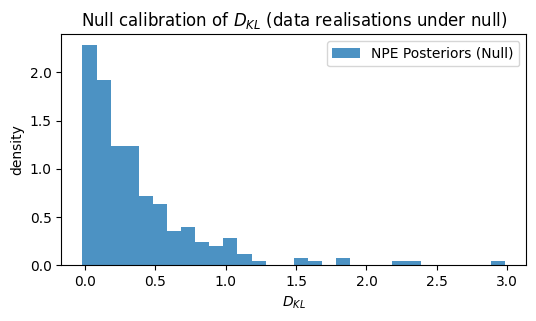

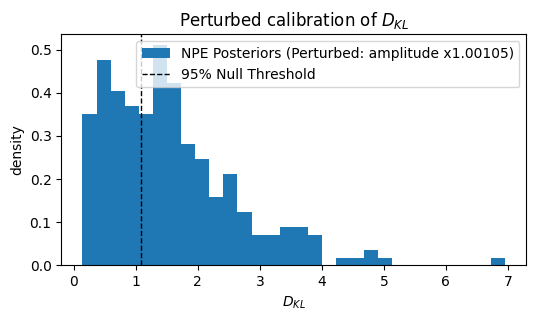

Null 95 percent critical value: 1.0806356608867644
Perturbed 95 percent critical value: 3.5822035789489743


In [27]:
multipliers_to_test = [1.00105, 1.0011]  # sweep beam_base * x
sensitivity_threshold_reached = False

for multiplier_val in multipliers_to_test:
    results = calibrate_null_dkl_and_perturb_mean(
        posterior1_direct, prior, 250, 500, my_compressor, nl_base, beam_base, multiplier=multiplier_val
    )
    null_threshold    = results[1]  # crit_val_95
    perturbed_median  = results[4]  # median_perturbed

    if perturbed_median >= null_threshold:
        print(f">>> 2-Sigma Sensitivity Reached at multiplier = {multiplier_val}! <<<")
        sensitivity_threshold_reached = True
        break  # We found our sensitivity limit, exit the loop

dkls                  = results[0]
crit_val_95           = results[1]
dkls_perturbed        = results[2]
crit_val_95_perturbed = results[3]
median_perturbed      = results[4]

# ==========================================
# NULL CALIBRATION PLOT
# ==========================================
plt.figure(figsize=(6, 3))
plt.hist(dkls, bins=30, density=True, alpha=0.8, color='tab:blue', label='NPE Posteriors (Null)')
plt.legend()
plt.xlabel(r"$D_{KL}$")
plt.ylabel("density")
plt.title(r"Null calibration of $D_{KL}$ (data realisations under null)")
plt.show()

# ==========================================
# PERTURBED CALIBRATION PLOT
# ==========================================
plt.figure(figsize=(6, 3))
plt.hist(dkls_perturbed, bins=30, density=True, color='tab:blue',
         label=f'NPE Posteriors (Perturbed: amplitude x{multiplier_val})')
plt.axvline(crit_val_95, color='black', linestyle='dashed', linewidth=1, label='95% Null Threshold')
plt.legend()
plt.xlabel(r"$D_{KL}$")
plt.ylabel("density")
plt.title(r"Perturbed calibration of $D_{KL}$")
plt.show()

print("Null 95 percent critical value:", crit_val_95)
print("Perturbed 95 percent critical value:", crit_val_95_perturbed)


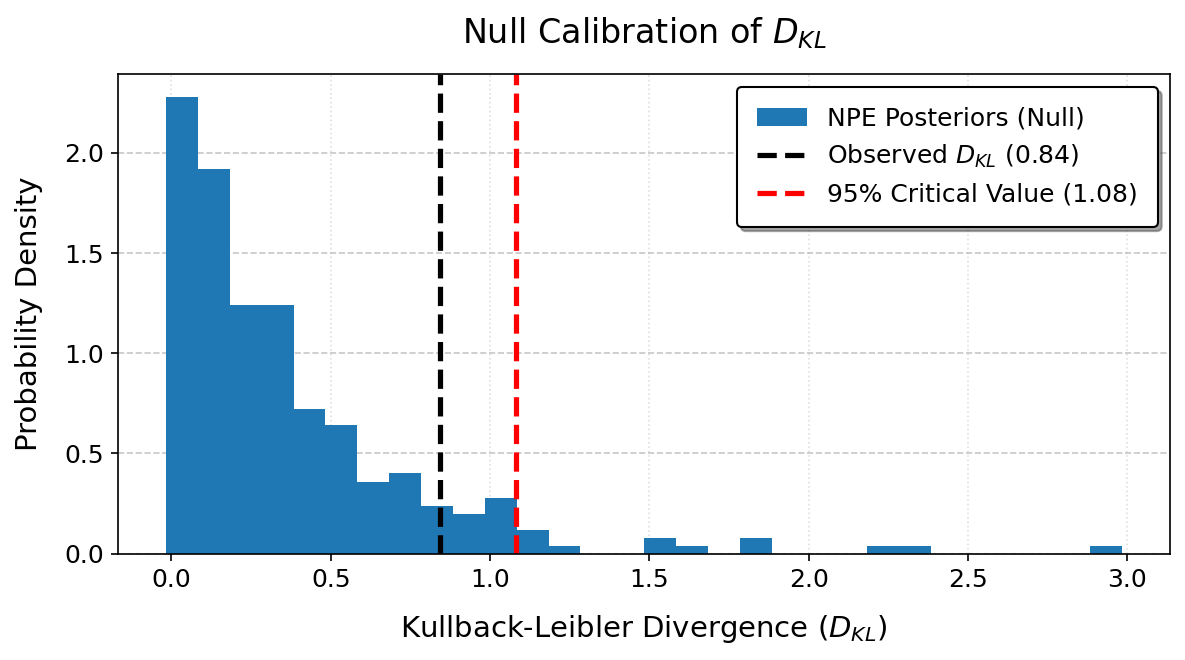

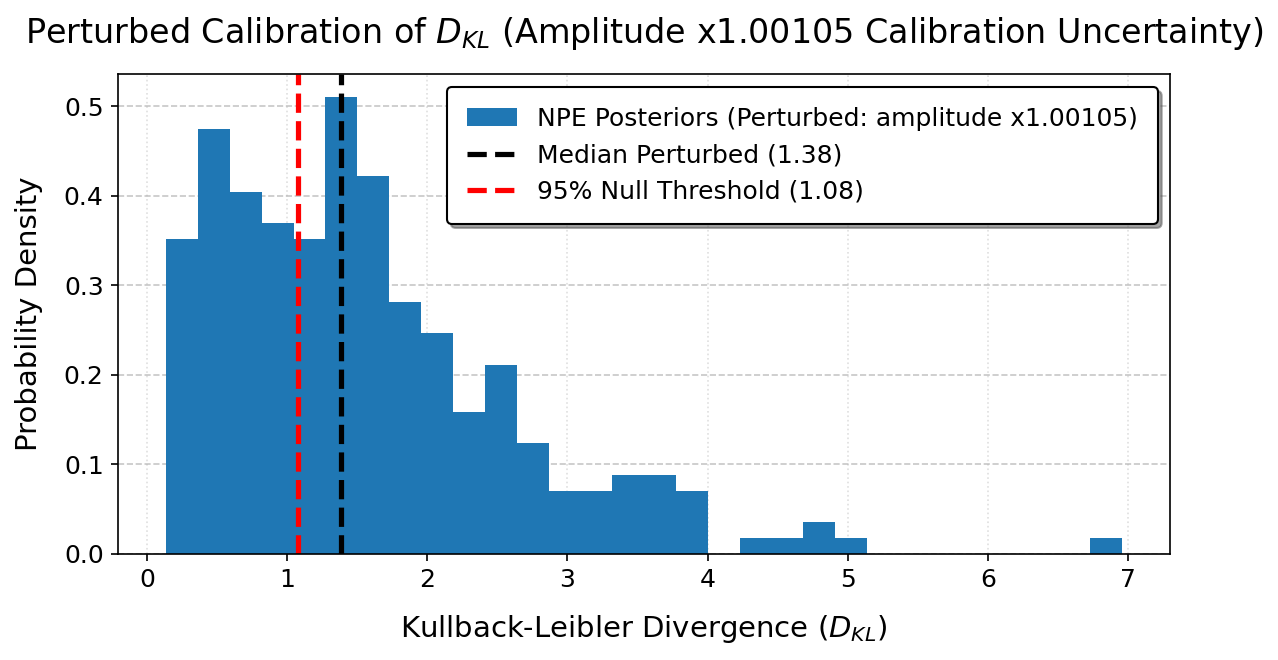

Null 95 percent critical value:      1.08
Perturbed 95 percent critical value: 3.58


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. NULL CALIBRATION GRAPH
# ==========================================
# Plot
plt.figure(figsize=(8, 4.5), dpi=150)

# Add a clean grid behind the histogram bars
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.grid(axis='x', linestyle=':', alpha=0.4) 

# Solid, opaque histogram bars
plt.hist(dkls, bins=30, density=True, color='tab:blue', label='NPE Posteriors (Null)')

plt.axvline(dkl_obs, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Observed $D_{{KL}}$ ({dkl_obs:.2f})')
plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
                label=f'95% Critical Value ({crit_val_95:.2f})')

# Upgraded labels and title
plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
plt.ylabel("Probability Density", fontsize=14, labelpad=10)
plt.title(r"Null Calibration of $D_{KL}$", fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Presentation-style legend
plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)

plt.tight_layout()
plt.show()


# ==========================================
# 2. PERTURBED CALIBRATION GRAPH
# ==========================================
plt.figure(figsize=(8, 4.5), dpi=150)

# Add a clean grid behind the histogram bars
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.grid(axis='x', linestyle=':', alpha=0.4) 

# Solid, opaque histogram bars
plt.hist(dkls_perturbed, bins=30, density=True, color='tab:blue',
         label=f'NPE Posteriors (Perturbed: amplitude x{multiplier_val:.5f})')

# Vertical threshold line (thicker, with dynamic value injected into legend)
plt.axvline(median_perturbed, color='black', linestyle='dashed', linewidth=2.5, 
                label=f'Median Perturbed ({median_perturbed:.2f})')
plt.axvline(crit_val_95, color='red', linestyle='dashed', linewidth=2.5, 
            label=f'95% Null Threshold ({crit_val_95:.2f})')

# Upgraded labels and title
plt.xlabel(r"Kullback-Leibler Divergence ($D_{KL}$)", fontsize=14, labelpad=10)
plt.ylabel("Probability Density", fontsize=14, labelpad=10)
plt.title(rf"Perturbed Calibration of $D_{{KL}}$ (Amplitude x{multiplier_val:.5f} Calibration Uncertainty)",
          fontsize=16, pad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Presentation-style legend
plt.legend(fontsize=12, frameon=True, shadow=True, facecolor='white', edgecolor='black', borderpad=0.8)

plt.tight_layout()
plt.show()

# Print statements formatted to 2 decimal places for neatness
print(f"Null 95 percent critical value:      {crit_val_95:.2f}")
print(f"Perturbed 95 percent critical value: {crit_val_95_perturbed:.2f}")


## Analytical Difference-Map chi^2 Test

Classical (non-SBI) null test: subtract the two splits, measure the difference
power spectrum, and test whether it is consistent with pure noise.

Model (full-sky, Gaussian a_lm):
```
a^(1)_lm = B_l s_lm + n^(1)_lm
a^(2)_lm = B_l s_lm + n^(2)_lm       (shared sky s, independent noise n^(i))
```

Difference map Delta a_lm = a^(1)_lm - a^(2)_lm: under the null the sky term
cancels exactly, leaving pure noise with

    <|Delta a_lm|^2> = N^(1)_l + N^(2)_l  =:  N^tot_l.

Pseudo-Cl estimator from full sky:

    Chat^Delta_l = (1/(2l+1)) * sum_m |Delta a_lm|^2
    <Chat^Delta_l> = N^tot_l
    (2l+1) Chat^Delta_l / N^tot_l  ~  chi^2_{2l+1}
    Var(Chat^Delta_l) = 2 (N^tot_l)^2 / (2l+1)

Different l are uncorrelated (statistical isotropy), so the covariance matrix
is diagonal. The Gaussian-likelihood chi^2 statistic is therefore

    T = sum_l (Chat^Delta_l - N^tot_l)^2 (2l+1) / [2 (N^tot_l)^2].

Under the `amplitude_scale = alpha` systematic (split 1's Cl multiplied by
alpha, equivalent to gain g = sqrt(alpha) on the alms), signal leakage
inflates <Chat^Delta_l> by (1 - g)^2 B_l^2 C^{TT}_l plus an O(epsilon) noise
term, which the chi^2 picks up primarily at low-l where B_l^2 C_l >> N_l.


In [ ]:
# Alm-level simulator — mirrors blanket_simulator but returns alms directly.
# gain = sqrt(amplitude_scale) reproduces the notebook's
# `cl_obs = amplitude_scale * cl_obs` at the alm level, which is the same
# systematic in expectation.

def simulator_alm_level(theta, nl_split, lmax=3000, beam_fwhm=5.0,
                         seed_cmb=None, seed_noise=None,
                         amplitude_scale=1.0):
    """Generate a single split's alm vector.

    Returns: alm (complex numpy array, healpy ordering)
    """
    theta = np.asarray(theta, dtype=float)

    # Pure theory spectrum (CAMB)
    cl_pure = get_camb_spectrum(theta, lmax=lmax)[:lmax+1]

    # Sky realisation (seed_cmb controls this — shared between splits)
    if seed_cmb is not None:
        np.random.seed(int(seed_cmb))
    cmb_alm = hp.synalm(cl_pure, lmax=lmax)

    # Beam
    beam = hp.gauss_beam(beam_fwhm / 60 / 180 * np.pi, lmax=lmax)
    cmb_alm_beamed = hp.almxfl(cmb_alm, beam)

    # Noise realisation (seed_noise independent between splits)
    if seed_noise is not None:
        np.random.seed(int(seed_noise))
    nl_formatted = np.asarray(nl_split)[:lmax+1]
    noise_alm = hp.synalm(nl_formatted, lmax=lmax)

    # Multiplicative gain = sqrt(amplitude_scale). This matches
    # blanket_simulator which does cl_obs = amplitude_scale * alm2cl(...).
    gain = np.sqrt(amplitude_scale)
    return gain * (cmb_alm_beamed + noise_alm)


def compute_chi2_diff(alm_1, alm_2, nl_1, nl_2, lmax=3000, lmin=2):
    """Gaussian-likelihood chi^2 of the difference power spectrum.

    T = sum_l (Chat^Delta_l - N^tot_l)^2 * (2l+1) / [2 (N^tot_l)^2]

    Under the null, T is approximately chi^2 with (lmax - lmin + 1) dof.
    """
    cl_diff = hp.alm2cl(alm_1 - alm_2, lmax=lmax)   # shape: (lmax+1,)
    ell = np.arange(lmax + 1)

    nl_1 = np.asarray(nl_1)[:lmax + 1]
    nl_2 = np.asarray(nl_2)[:lmax + 1]
    mu_null  = nl_1 + nl_2                           # expected under null
    var_null = 2.0 * mu_null**2 / (2 * ell + 1)      # shape: (lmax+1,)

    use = slice(lmin, lmax + 1)
    return float(np.sum((cl_diff[use] - mu_null[use])**2 / var_null[use]))


In [ ]:
# One realisation of the chi^2 statistic:
#   draw theta ~ prior, simulate two splits with shared sky + independent noise,
#   apply amplitude_scale to split 1, return chi^2.
#
# We sample theta from the prior so the null distribution mirrors the KL
# calibration exactly (same-sky seeds, matched noise/beam). Under the null
# (amplitude_scale=1) the signal cancels so theta is irrelevant — the chi^2
# distribution is independent of cosmology. Under the systematic, theta sets
# the CMB power that leaks in, so prior sampling is the correct fairness
# condition to compare against the SBI pipeline.

def one_chi2_realisation(seed, prior, nl_base, beam_base, amplitude_scale):
    """Single realisation: theta sampled from prior, seed controls sky/noise."""
    # Fix the per-realisation randomness so each worker draws the same theta
    # regardless of joblib scheduling.
    torch.manual_seed(int(seed))
    theta_i = np.asarray(prior.sample((1,)).squeeze(0), dtype=float)

    alm_1 = simulator_alm_level(
        theta_i, nl_base, lmax=3000, beam_fwhm=beam_base,
        seed_cmb=int(seed), seed_noise=int(seed) + 1_000_000,
        amplitude_scale=amplitude_scale,
    )
    alm_2 = simulator_alm_level(
        theta_i, nl_base, lmax=3000, beam_fwhm=beam_base,
        seed_cmb=int(seed), seed_noise=int(seed) + 2_000_000,
        amplitude_scale=1.0,
    )
    return compute_chi2_diff(alm_1, alm_2, nl_base, nl_base, lmax=3000, lmin=2)


def chi2_distribution(N, prior, nl_base, beam_base, amplitude_scale, n_jobs=8, seed_offset=0):
    """Parallel evaluation of N realisations of T at fixed amplitude_scale."""
    seeds = np.arange(N) + seed_offset
    return np.asarray(Parallel(n_jobs=n_jobs)(
        delayed(one_chi2_realisation)(s, prior, nl_base, beam_base, amplitude_scale)
        for s in seeds
    ), dtype=float)


In [ ]:
# Null calibration of the chi^2 statistic (amplitude_scale = 1.0).
# The expected mean under the null is N_modes = lmax - lmin + 1 = 2999.

N_calib = 200
T_null = chi2_distribution(
    N_calib, prior, nl_base, beam_base,
    amplitude_scale=1.0, n_jobs=8, seed_offset=0,
)

N_modes = 3000 - 2 + 1
crit95_chi2 = float(np.quantile(T_null, 0.95))
print(f"Null chi^2: mean={T_null.mean():.1f}  std={T_null.std(ddof=1):.1f}  "
      f"(expected mean={N_modes}, expected std~{np.sqrt(2*N_modes):.1f})")
print(f"95% critical value: {crit95_chi2:.1f}")

plt.figure(figsize=(8, 4.5), dpi=150)
plt.gca().set_axisbelow(True)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle=":",  alpha=0.4)
plt.hist(T_null, bins=30, density=True, color="tab:blue",
         label=fr"Null distribution ($\alpha=1$)")
plt.axvline(crit95_chi2, color="red", linestyle="dashed", linewidth=2.5,
            label=f"95% critical value ({crit95_chi2:.1f})")
plt.axvline(N_modes, color="grey", linestyle=":", linewidth=2,
            label=fr"Analytic mean ($N_{{\rm modes}}={N_modes}$)")
plt.xlabel(r"Difference-map $\chi^2$ statistic $T$", fontsize=14, labelpad=10)
plt.ylabel("Probability density", fontsize=14, labelpad=10)
plt.title(r"Null calibration of analytic $\chi^2$ difference test", fontsize=16, pad=15)
plt.legend(fontsize=12, frameon=True, shadow=True, facecolor="white", edgecolor="black", borderpad=0.8)
plt.tight_layout()
plt.show()


In [ ]:
# Perturbed distribution at the same amplitude_systematic used by the SBI pipeline.
# Compare the perturbed median to the 95% null threshold — if it exceeds,
# this systematic is detectable by the classical test.

T_perturbed = chi2_distribution(
    N_calib, prior, nl_base, beam_base,
    amplitude_scale=amplitude_systematic, n_jobs=8, seed_offset=0,
)

median_perturbed_chi2 = float(np.median(T_perturbed))
print(f"Perturbed chi^2 at alpha={amplitude_systematic}:  "
      f"mean={T_perturbed.mean():.1f}  median={median_perturbed_chi2:.1f}")
print(f"Null 95% threshold:       {crit95_chi2:.1f}")
print(f"Detectable? {'YES' if median_perturbed_chi2 >= crit95_chi2 else 'no'} "
      "(perturbed median vs 95% null threshold)")

plt.figure(figsize=(8, 4.5), dpi=150)
plt.gca().set_axisbelow(True)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle=":",  alpha=0.4)
plt.hist(T_null,      bins=30, density=True, color="tab:blue",   alpha=0.65, label="Null")
plt.hist(T_perturbed, bins=30, density=True, color="tab:orange", alpha=0.65,
         label=fr"Perturbed ($\alpha$={amplitude_systematic})")
plt.axvline(crit95_chi2, color="red", linestyle="dashed", linewidth=2.5,
            label=f"95% null threshold ({crit95_chi2:.1f})")
plt.axvline(median_perturbed_chi2, color="black", linestyle="dashed", linewidth=2.5,
            label=f"Perturbed median ({median_perturbed_chi2:.1f})")
plt.xlabel(r"Difference-map $\chi^2$ statistic $T$", fontsize=14, labelpad=10)
plt.ylabel("Probability density", fontsize=14, labelpad=10)
plt.title(r"Analytic $\chi^2$: null vs calibration-uncertainty perturbation",
          fontsize=16, pad=15)
plt.legend(fontsize=12, frameon=True, shadow=True, facecolor="white", edgecolor="black", borderpad=0.8)
plt.tight_layout()
plt.show()


In [ ]:
# Amplitude sweep — find the smallest alpha at which the analytic chi^2
# test detects the systematic (perturbed median >= 95% null threshold).
# Mirrors the KL-sensitivity sweep above so the two tests can be compared
# head-to-head.

chi2_sweep_alphas = [1.00025, 1.0005, 1.00075, 1.00105, 1.0011, 1.00125]
chi2_sweep_rows = []

for alpha in chi2_sweep_alphas:
    T_alpha = chi2_distribution(
        N_calib, prior, nl_base, beam_base,
        amplitude_scale=alpha, n_jobs=8, seed_offset=0,
    )
    med   = float(np.median(T_alpha))
    detected = med >= crit95_chi2
    chi2_sweep_rows.append((alpha, med, detected))
    print(f"alpha={alpha:.5f}  median T={med:8.1f}  "
          f"null 95%={crit95_chi2:8.1f}  detected={detected}")

print()
print("alpha      median T   detected")
for alpha, med, det in chi2_sweep_rows:
    print(f"{alpha:.5f}   {med:8.1f}   {det}")
